# V2G in Thailand: modelling assessment teaser

**TGC–EMC stakeholder dissemination workshop — 17 September 2026**

This event notebook presents a short, decision-oriented selection of the FLEXIMOD electric-bus depot results. It is designed for approximately ten minutes of presentation time and reuses the completed annual output files from the full analysis notebook.

> A bus depot is a controllable and measurable flexibility resource, but the value of V2G in Thailand depends on the service provided, compensation, regulation, metering, and mobility protection.

Run from the FLEXIMOD project root. Missing annual outputs remain visibly unavailable; they are never silently treated as zero.


## 1. Study boundary and interpretation

The model represents three individually modelled electric buses, route energy, bus availability, managed charging, V2G discharge, grid import/export, tariffs, rooftop PV, renewable-availability proxies, and synthetic emergency islanding sensitivities.

It excludes non-traction building demand, vehicle purchase costs, charger/PV/grid-upgrade investment, battery-degradation costs, and unmodelled social benefits.

Important interpretation limits:

- The peak-demand signal is a power-system peak-demand proxy, not measured feeder congestion.
- Renewable metrics are availability-weighted model proxies, not claims of metered renewable electrons.
- I08 is technical islanded fleet-V2G transfer potential, not confirmed external critical-load supply or an observed Thai outage.
- The PDP2026 document is a draft open for consultation; it informs future sensitivity framing but does not establish V2G market permission or tariffs.


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn as sns
import seaborn as sns
import seaborn as sns
from flexi_mod.analysis.building_case_analysis import build_service_cost_gap, result_availability, stakeholder_matrix
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find the FLEXIMOD project root')


PROJECT_ROOT = find_project_root()
INPUT_ROOT = PROJECT_ROOT / 'data' / 'input'
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'output' / 'building_use_case_analysis'
SOURCE_ROOT = PROJECT_ROOT / 'docs' / 'sources'
FORECAST_PATH = INPUT_ROOT / 'building_v1g_annual' / 'forecasts_df.csv'
ROOF_PATH = SOURCE_ROOT / 'borom_depot_roof_polygons.geojson'
ROUTE_PATH = SOURCE_ROOT / 'modeled_bus_route_corridors.geojson'

RUN_MISSING_CORE_CASES = False
RUN_SENSITIVITY_CASES = False

# D0 documented 2024 assumptions; see docs/sources/diesel_reference_2024.md.
DIESEL_FUEL_CONSUMPTION_L_PER_KM = 1.0 / 2.55  # BMTA diesel-bus average.
DIESEL_PRICE_THB_PER_L = 31.89  # 2024 national average retail diesel price.
DIESEL_TAILPIPE_CO2_KG_PER_L = 2.5503727392  # B7 fossil Scope 1, including CH4 and N2O.
DIESEL_BIOGENIC_CO2_KG_PER_L = 0.11507832  # B7 biogenic CO2, reported separately.
DIESEL_CARBON_TAX_THB_PER_L = 0.0  # No separate automobile carbon tax in 2024.
GRID_CO2_KG_PER_MWH = 499.9
CREDIT_GRID_EXPORT = False

CORE_CASES = {
    'V1G baseline': {'input': 'building_v1g_annual', 'study_case': 'building_v1g_annual', 'output': 'v1g_baseline'},
    'PV + unidirectional charging reference': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2b_rooftop_pv'},
    'I02a least-cost V2G at current feed-in tariff': {'input': 'building_v2b_cost_annual', 'study_case': 'building_v2b_cost_annual', 'output': 'v2b_cost'},
    'I02b economically viable V2G export': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': 'building_v2g_sweep_plus_1000', 'output': 'tariff_plus_1000'},
    'I03 maximum power-system peak-demand import reduction without export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export'},
    'I04a maximum power-system peak-demand import reduction at 5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw'},
    'I04b maximum power-system peak-demand import reduction at 450 kW technical sensitivity': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw'},
    'I05 maximum renewable-deficit support without export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export'},
    'I06a maximum renewable-deficit support at 5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw'},
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw'},
    'I07b rooftop PV operation at current export policy': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2g_pv_current_policy'},
    'I07c rooftop PV operation at viable export tariff': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_export_viable_tariff', 'output': 'v2g_pv_viable_tariff'},
    'I07d PV with power-system peak-demand management': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_cost_capped_high_load_relief', 'output': 'v2g_pv_cost_capped_high_load_relief'},
    'I08a-P emergency V2G 4 h prepared SOC': {'input': 'building_v2g_emergency_backup_4h_prepared', 'study_case': 'building_v2g_emergency_backup_4h_prepared', 'output': 'i08_4h_prepared'},
    'I08a-B emergency V2G 4 h inherited SOC': {'input': 'building_v2g_emergency_backup_4h_baseline', 'study_case': 'building_v2g_emergency_backup_4h_baseline', 'output': 'i08_4h_baseline'},
    'I08b-P emergency V2G 8 h prepared SOC': {'input': 'building_v2g_emergency_backup_8h_prepared', 'study_case': 'building_v2g_emergency_backup_8h_prepared', 'output': 'i08_8h_prepared'},
    'I08b-B emergency V2G 8 h inherited SOC': {'input': 'building_v2g_emergency_backup_8h_baseline', 'study_case': 'building_v2g_emergency_backup_8h_baseline', 'output': 'i08_8h_baseline'},
    'V2G current feed-in tariff': {'input': 'building_v2g_current_tariff_annual', 'study_case': 'building_v2g_current_tariff_annual', 'output': 'v2g_current_export'},
}
GRID_SUPPORT_CASES = {
    'No export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw', 'export_limit_kw': 450},
}
RENEWABLE_CASES = {
    'No export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw', 'export_limit_kw': 450},
}
TARIFF_CASES = {f'Export +{increment / 1000:.1f} THB/kWh': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': ('building_v2g_sweep_current' if increment == 0 else f'building_v2g_sweep_plus_{increment}'), 'output': f'tariff_plus_{increment}', 'increment_thb_per_kwh': increment / 1000} for increment in range(0, 5001, 500)}

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05, rc={'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'semibold', 'figure.dpi': 120, 'savefig.dpi': 300})
COLORS = {'blue': '#0072B2', 'orange': '#D55E00', 'green': '#009E73', 'purple': '#7B61A8', 'grey': '#6B7280'}
print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis outputs: {OUTPUT_ROOT}')


Project root: /root/FLEXIMOD
Analysis outputs: /root/FLEXIMOD/data/output/building_use_case_analysis


In [2]:
def output_dir(spec: dict) -> Path:
    return OUTPUT_ROOT / spec['output']


def run_case(label: str, spec: dict, allow_run: bool) -> None:
    destination = output_dir(spec)
    summary_path = destination / 'summary_indicators.csv'
    dispatch_path = destination / 'dispatch_results.csv'
    if summary_path.exists() and dispatch_path.exists():
        return
    if not allow_run:
        print(f'Missing {label}: {destination}')
        return
    destination.mkdir(parents=True, exist_ok=True)
    command = [sys.executable, '-m', 'flexi_mod.simulation.run_case', '--case', str(INPUT_ROOT / spec['input']), '--study-case', spec['study_case'], '--output-dir', str(destination), '--no-plots']
    print(f'Running {label}')
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)


for label, spec in CORE_CASES.items():
    run_case(label, spec, RUN_MISSING_CORE_CASES)

print('Core annual outputs available:', sum((output_dir(spec) / 'summary_indicators.csv').exists() for spec in CORE_CASES.values()), '/', len(CORE_CASES))


Core annual outputs available: 18 / 18


## 2. Five headline use cases for the workshop

| Family | Headline case(s) | Dispatch strategy | Main question / teaser finding |
| --- | --- | --- | --- |
| Reference | **V1G** | V1G managed charging | What does ordinary electric-bus operation cost relative to diesel? |
| Economic V2G | **I02a → I02b**<br>2.20 → 3.20 THB/kWh feed-in tariff | Minimise operating cost; change only export remuneration | At what payment does the depot begin exporting? **0 MWh at 2.20; 1.428 MWh/year at 3.20 THB/kWh.** |
| Peak-demand import reduction | **I04a → I04b**<br>5 kW current policy limit → 450 kW technical sensitivity | Maximise depot net-import relief during selected power-system peak-demand periods | How much can V2G reduce the depot’s net electricity draw during power-system peak-demand hours? **92 kW / 3.578 MWh/year at the 5 kW policy limit; 387 kW / 9.626 MWh/year at the technical sensitivity.** |
| Renewable alignment | **I06a**<br>5 kW current policy export limit | Shift charging and limited export against the renewable-availability proxy | Can V2G store electricity when renewable availability is higher and export it when availability is lower? |
| Rooftop PV operation | **I07b / I07d**<br>current 5 kW policy limit | Optimise PV self-consumption and surplus export; defer charging during power-system peak-demand periods without higher operating cost | What immediate value does PV create, and can it reduce peak-demand-period grid draw? |

The remaining cases are retained as sensitivities to interpret policy limits, technical ceilings and alternative service designs. D0 diesel is retained only as the mobility and traction-emissions benchmark. “Peak-demand” is a power-system peak-demand proxy, not verified feeder congestion; renewable alignment uses a common model proxy.


In [3]:
forecast = pd.read_csv(FORECAST_PATH, parse_dates=['datetime']).set_index('datetime')
distance_columns = [column for column in forecast if column.endswith('_trip_distance_km')]
if not distance_columns:
    raise ValueError('No per-bus trip-distance columns were found')
dt_hours = float(forecast.index.to_series().diff().dropna().dt.total_seconds().median() / 3600)
route_totals = forecast[distance_columns].sum().rename(lambda value: value.removesuffix('_trip_distance_km')).rename('annual_distance_km')
print(f'Modelled annual bus distance: {route_totals.sum():,.0f} km')

total_distance_km = float(route_totals.sum())
diesel_litre = total_distance_km * DIESEL_FUEL_CONSUMPTION_L_PER_KM
diesel_fuel_cost = diesel_litre * (DIESEL_PRICE_THB_PER_L + DIESEL_CARBON_TAX_THB_PER_L)
diesel_bus_scope1_co2 = diesel_litre * DIESEL_TAILPIPE_CO2_KG_PER_L
diesel_biogenic_co2 = diesel_litre * DIESEL_BIOGENIC_CO2_KG_PER_L
diesel_total_cost = diesel_fuel_cost
diesel_operational_co2 = diesel_bus_scope1_co2

diesel_row = {
    'scenario': 'Diesel benchmark', 'distance_km': total_distance_km, 'fuel_litre': diesel_litre,
    'diesel_fuel_cost_THB': diesel_fuel_cost, 'diesel_carbon_tax_THB': diesel_litre * DIESEL_CARBON_TAX_THB_PER_L,
    'energy_cost_THB': diesel_fuel_cost, 'demand_charge_THB': 0.0, 'total_cost_THB': diesel_total_cost,
    'grid_import_MWh': 0.0, 'grid_export_MWh': 0.0,
    'peak_grid_import_MW': 0.0, 'operational_CO2_kg': float(diesel_operational_co2),
    'diesel_bus_scope1_CO2e_kg': float(diesel_bus_scope1_co2), 'diesel_biogenic_CO2_kg': float(diesel_biogenic_co2),
    'pv_available_MWh': 0.0, 'pv_used_MWh': 0.0, 'pv_curtailment_MWh': 0.0,
    'grid_import_during_stress_MWh': 0.0,
    'renewable_alignment_score': np.nan,
}
print('Diesel benchmark prepared for common comparison.')


Modelled annual bus distance: 295,728 km
Diesel benchmark prepared for common comparison.


In [4]:
def load_result(label: str, spec: dict) -> tuple[dict, pd.DataFrame] | None:
    summary_path = output_dir(spec) / 'summary_indicators.csv'
    dispatch_path = output_dir(spec) / 'dispatch_results.csv'
    if not summary_path.exists() or not dispatch_path.exists():
        return None
    summary = pd.read_csv(summary_path).iloc[0]
    dispatch = pd.read_csv(dispatch_path, parse_dates=['datetime']).set_index('datetime')
    # Apply one common 2024 renewable-availability signal to every case.
    # Most cases do not need the signal to optimise, but all cases need it for a fair comparison.
    signal_path = INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv'
    signal_frame = pd.read_csv(signal_path, usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'], parse_dates=['datetime']).set_index('datetime')
    renewable_rich_threshold = float(signal_frame['renewable_rich_threshold'].iloc[0])
    signal = signal_frame['renewable_availability_weight']
    signal.index = signal.index.tz_localize(dispatch.index.tz)
    dispatch['renewable_availability_weight'] = signal.reindex(dispatch.index)
    if dispatch['renewable_availability_weight'].isna().any():
        raise ValueError(f'Renewable signal does not cover {label}')
    # This is an availability-weighted charging indicator, not a claim about metered renewable electrons.
    common_renewable_absorbed = float((dispatch['bus_charge_MWh'] * dispatch['renewable_availability_weight']).sum())
    renewable_rich_charge = float(dispatch.loc[dispatch['renewable_availability_weight'] >= renewable_rich_threshold, 'bus_charge_MWh'].sum())
    # Study boundary: traction charging and V2X only.  A legacy output may contain
    # a building-demand column, so remove it before calculating electric-case KPIs.
    legacy_building_demand = dispatch.get('building_demand_MWh', pd.Series(0.0, index=dispatch.index))
    dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
    dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
    dispatch['traction_net_grid_import_MWh'] = dispatch['traction_grid_import_MWh'] - dispatch['grid_export_MWh']
    imported_co2 = float(dispatch['traction_grid_import_MWh'].sum()) * GRID_CO2_KG_PER_MWH
    export_credit = float(dispatch['grid_export_MWh'].sum()) * GRID_CO2_KG_PER_MWH if CREDIT_GRID_EXPORT else 0.0
    row = {
        'scenario': label, 'distance_km': float(summary['total_bus_trip_distance_km']), 'fuel_litre': 0.0,
        'energy_cost_THB': float(summary['total_energy_cost']), 'demand_charge_THB': float(summary['total_demand_charge_cost']),
        'total_cost_THB': float(summary['total_cost']), 'grid_import_MWh': float(dispatch['traction_grid_import_MWh'].sum()),
        'grid_export_MWh': float(summary['total_grid_export_MWh']), 'peak_grid_import_MW': float(dispatch['traction_grid_import_MWh'].max() / 0.25),
        'peak_grid_export_MW': float(summary.get('peak_grid_export_MW', 0.0)),
        'unmet_trip_energy_MWh': float(summary.get('total_unmet_trip_energy_MWh', 0.0)),
        'operational_CO2_kg': imported_co2 - export_credit,
        'pv_available_MWh': float(summary.get('total_pv_available_generation_MWh', 0.0)),
        'pv_used_MWh': float(summary.get('total_pv_generation_MWh', 0.0)),
        'pv_curtailment_MWh': float(summary.get('total_pv_curtailment_MWh', 0.0)),
        'grid_import_during_stress_MWh': float(summary.get('grid_import_during_regional_stress_MWh', np.nan)),
        'renewable_alignment_score': float(summary.get('renewable_alignment_score', np.nan)),
        'renewable_absorbed_MWh': common_renewable_absorbed,
        'renewable_rich_charge_MWh': renewable_rich_charge,
        'renewable_signal_mean': float(dispatch['renewable_availability_weight'].mean()),
        'renewable_tagged_absorbed_MWh': float(summary.get('renewable_equivalent_absorbed_MWh', 0.0)),
        'renewable_delivered_MWh': float(summary.get('renewable_equivalent_delivered_MWh', 0.0)),
        'renewable_to_site_MWh': float(summary.get('renewable_equivalent_discharge_to_site_MWh', 0.0)),
        'renewable_export_MWh': float(summary.get('renewable_equivalent_grid_export_MWh', 0.0)),
        'renewable_conversion_loss_MWh': float(summary.get('renewable_equivalent_conversion_loss_MWh', 0.0)),
        'renewable_deficit_support_MWh': float(summary.get('renewable_deficit_weighted_discharge_MWh', 0.0)),
        'emergency_transfer_MWh': float(summary.get('emergency_v2g_transfer_MWh', 0.0)),
        'peak_emergency_transfer_MW': float(summary.get('peak_emergency_v2g_transfer_MW', 0.0)),
        'synthetic_outage_duration_hours': float(summary.get('synthetic_outage_duration_hours', 0.0)),
        'recovery_grid_import_MWh': float(summary.get('recovery_grid_import_MWh', 0.0)),
    }
    return row, dispatch


electric_rows = []
dispatch_by_case = {}
for label, spec in CORE_CASES.items():
    loaded = load_result(label, spec)
    if loaded is not None:
        row, dispatch = loaded
        electric_rows.append(row)
        dispatch_by_case[label] = dispatch

if 'V1G baseline' in dispatch_by_case:
    baseline_dispatch = dispatch_by_case['V1G baseline']
    for row in electric_rows:
        label = row['scenario']
        dispatch = dispatch_by_case[label]
        common_index = baseline_dispatch.index.intersection(dispatch.index)
        baseline_net = baseline_dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        case_net = dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        relief = baseline_net - case_net
        weight = dispatch.loc[common_index, 'grid_congestion_weight']
        threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
        stressed = weight >= threshold
        row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row['maximum_grid_support_MW'] = float(relief.max() / 0.25)
        row['rebound_import_MWh'] = float((-relief.loc[~stressed]).clip(lower=0).sum())

comparison = pd.DataFrame([diesel_row, *electric_rows]).set_index('scenario')
comparison['cost_THB_per_km'] = comparison['total_cost_THB'] / comparison['distance_km']
comparison['operational_CO2_kg_per_km'] = comparison['operational_CO2_kg'] / comparison['distance_km']
if 'V1G baseline' in comparison.index:
    reference = comparison.loc['V1G baseline']
    comparison['cost_saving_vs_V1G_pct'] = 100 * (reference['total_cost_THB'] - comparison['total_cost_THB']) / reference['total_cost_THB']
    comparison['peak_reduction_vs_V1G_pct'] = 100 * (reference['peak_grid_import_MW'] - comparison['peak_grid_import_MW']) / reference['peak_grid_import_MW']
else:
    comparison['cost_saving_vs_V1G_pct'] = np.nan
    comparison['peak_reduction_vs_V1G_pct'] = np.nan
columns = ['distance_km', 'total_cost_THB', 'cost_THB_per_km', 'cost_saving_vs_V1G_pct', 'grid_import_MWh', 'grid_export_MWh', 'peak_grid_import_MW', 'peak_grid_export_MW', 'grid_support_during_stress_MWh', 'maximum_grid_support_MW', 'rebound_import_MWh', 'renewable_absorbed_MWh', 'renewable_rich_charge_MWh', 'renewable_tagged_absorbed_MWh', 'renewable_delivered_MWh', 'renewable_to_site_MWh', 'renewable_export_MWh', 'renewable_conversion_loss_MWh', 'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh', 'pv_used_MWh', 'pv_curtailment_MWh']
print(f'Completed annual outputs loaded: {len(dispatch_by_case)} cases')


/tmp/ipykernel_2144842/1089244713.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_2144842/1089244713.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_2144842/1089244713.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

/tmp/ipykernel_2144842/1089244713.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_2144842/1089244713.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_2144842/1089244713.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

/tmp/ipykernel_2144842/1089244713.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_2144842/1089244713.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_2144842/1089244713.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Completed annual outputs loaded: 18 cases


## 3. Economic V2G: feed-in tariff determines dispatch

**Comparison:** V1G managed-charging reference versus I02a at the current 2.20 THB/kWh feed-in tariff and I02b at the illustrative 3.20 THB/kWh payment. I02b is the first tested tariff point above the approximate 3.10 THB/kWh efficiency-based break-even estimate; it is an operating-cost sensitivity, not a tariff recommendation.


findfont: Failed to find font weight semibold, now using 700.


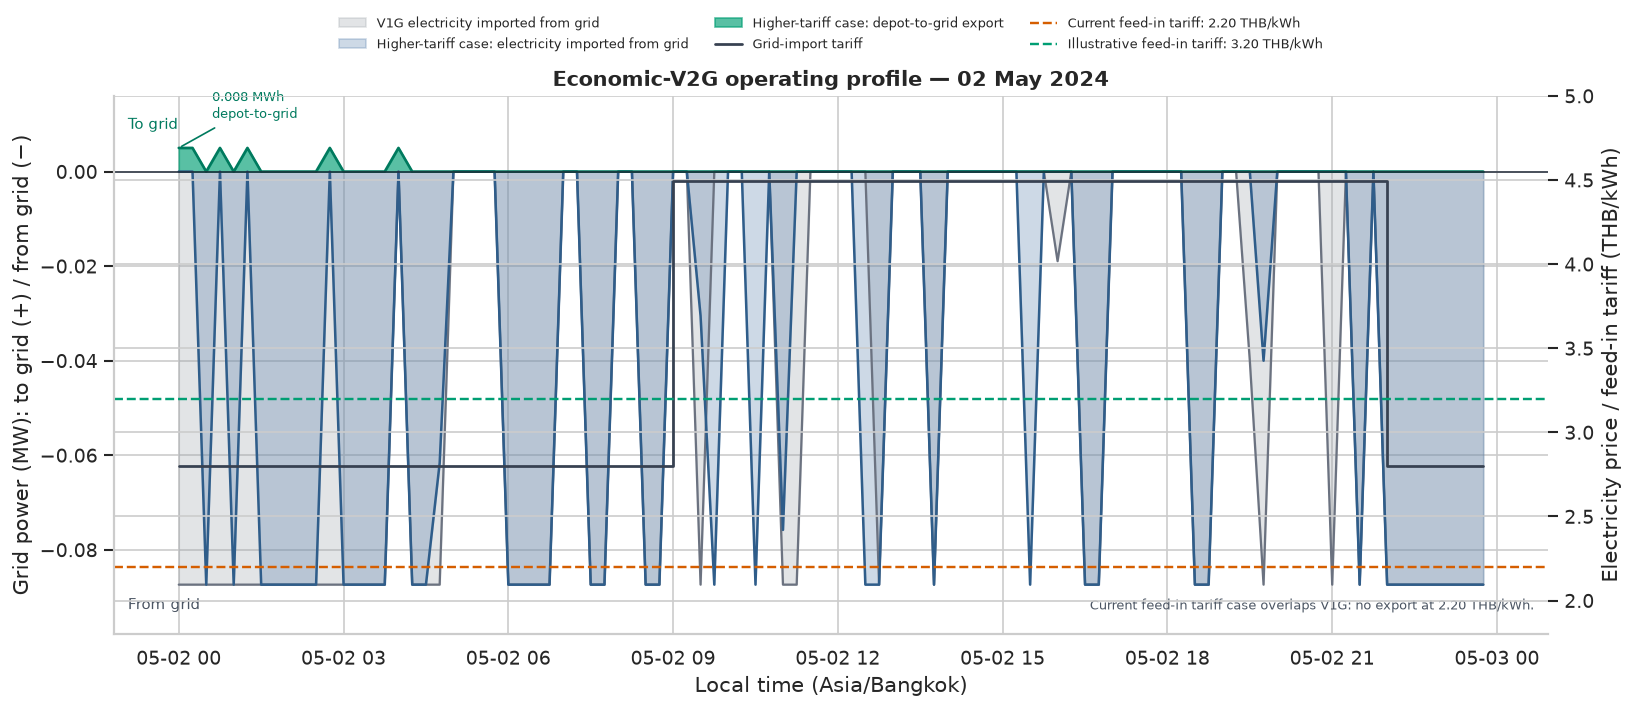

In [5]:
i01_label = 'V1G baseline'
i02a_label = 'I02a least-cost V2G at current feed-in tariff'
i02b_label = 'I02b economically viable V2G export'

required = [i01_label, i02a_label, i02b_label]
missing = [label for label in required if label not in dispatch_by_case or label not in comparison.index]
if missing:
    print(f'Missing completed economic-case outputs: {missing}')
else:
    i01 = dispatch_by_case[i01_label].copy()
    i02a = dispatch_by_case[i02a_label].copy()
    i02b = dispatch_by_case[i02b_label].copy()
    for frame in (i01, i02a, i02b):
        frame.index = pd.to_datetime(frame.index)

    # Illustrative normal working day with the greatest I02b depot-to-grid energy.
    daily_export = i02b['grid_export_MWh'].groupby(i02b.index.date).sum()
    holiday_by_day = forecast['is_public_holiday'].groupby(forecast.index.date).max()
    working_days = [day for day in daily_export.index if pd.Timestamp(day).weekday() < 5 and not bool(holiday_by_day.get(day, False))]
    selected_day = daily_export.loc[working_days].idxmax() if working_days else daily_export.idxmax()
    i01_day = i01.loc[i01.index.date == selected_day].copy()
    i02b_day = i02b.loc[i02b.index.date == selected_day].copy()
    export_day = i02b_day['grid_export_MWh'].sum()

    # Convention: electricity taken from the grid is below zero; electricity delivered
    # from the depot to the grid is above zero.
    i01_import_power = i01_day['grid_import_MWh'] / 0.25
    i02b_import_power = i02b_day['grid_import_MWh'] / 0.25
    i02b_export_power = i02b_day['grid_export_MWh'] / 0.25
    import_price = i02b_day['electricity_import_price_THB_per_MWh'] / 1000

    fig, power_axis = plt.subplots(figsize=(13.5, 5.8), constrained_layout=True)
    power_axis.fill_between(i01_day.index, -i01_import_power, 0, color='#9AA0A6', alpha=0.28, label='V1G electricity imported from grid')
    power_axis.plot(i01_day.index, -i01_import_power, color='#6B7280', linewidth=1.35)
    power_axis.fill_between(i02b_day.index, -i02b_import_power, 0, color='#4C78A8', alpha=0.28, label='Higher-tariff case: electricity imported from grid')
    power_axis.plot(i02b_day.index, -i02b_import_power, color='#2F5D8A', linewidth=1.5)
    power_axis.fill_between(i02b_day.index, 0, i02b_export_power, color='#009E73', alpha=0.65, label='Higher-tariff case: depot-to-grid export')
    power_axis.plot(i02b_day.index, i02b_export_power, color='#007A5E', linewidth=1.6)
    power_axis.axhline(0, color='#1F2937', linewidth=0.9)
    power_axis.set_ylabel('Grid power (MW): to grid (+) / from grid (−)')
    power_axis.set_xlabel('Local time (Asia/Bangkok)')
    power_axis.set_title(f'Economic-V2G operating profile — {pd.Timestamp(selected_day):%d %b %Y}')
    power_axis.text(0.01, 0.04, 'From grid', transform=power_axis.transAxes, color='#4B5563', fontsize=9, va='bottom')
    power_axis.text(0.01, 0.96, 'To grid', transform=power_axis.transAxes, color='#007A5E', fontsize=9, va='top')
    power_axis.set_ylim(-1.12 * max(i01_import_power.max(), i02b_import_power.max()), max(0.016, 1.6 * i02b_export_power.max()))

    tariff_axis = power_axis.twinx()
    tariff_axis.step(i02b_day.index, import_price, where='post', color='#374151', linewidth=1.65, label='Grid-import tariff')
    tariff_axis.axhline(2.20, color='#D55E00', linewidth=1.45, linestyle='--', label='Current feed-in tariff: 2.20 THB/kWh')
    tariff_axis.axhline(3.20, color='#009E73', linewidth=1.45, linestyle='--', label='Illustrative feed-in tariff: 3.20 THB/kWh')
    tariff_axis.set_ylabel('Electricity price / feed-in tariff (THB/kWh)')
    tariff_axis.set_ylim(1.8, 5.0)

    handles_1, labels_1 = power_axis.get_legend_handles_labels()
    handles_2, labels_2 = tariff_axis.get_legend_handles_labels()
    power_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=3, frameon=False, fontsize=8)
    power_axis.annotate(f'{export_day:.3f} MWh\ndepot-to-grid', xy=(i02b_day.index[i02b_export_power.argmax()], i02b_export_power.max()), xytext=(20, 18), textcoords='offset points', color='#007A5E', fontsize=8, arrowprops={'arrowstyle': '-', 'color': '#007A5E'})
    power_axis.text(0.99, 0.04, 'Current feed-in tariff case overlaps V1G: no export at 2.20 THB/kWh.', transform=power_axis.transAxes, ha='right', va='bottom', fontsize=8, color='#4B5563')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


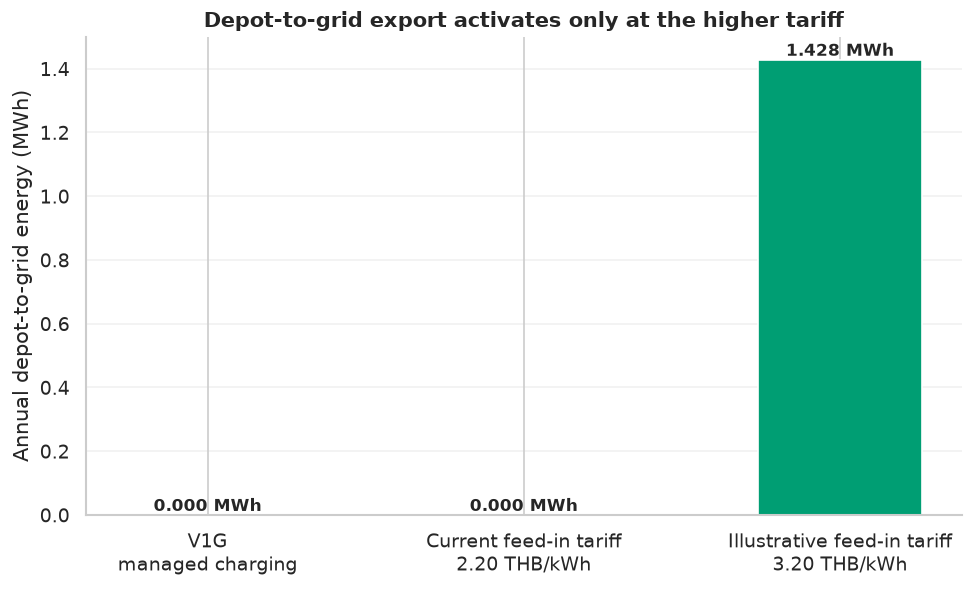

In [6]:
if not missing:
    cases = [i01_label, i02a_label, i02b_label]
    labels = ['V1G\nmanaged charging', 'Current feed-in tariff\n2.20 THB/kWh', 'Illustrative feed-in tariff\n3.20 THB/kWh']
    depot_to_grid_mwh = [float(dispatch_by_case[case]['grid_export_MWh'].sum()) for case in cases]
    peak_i02b_kw = float(dispatch_by_case[i02b_label]['grid_export_MWh'].max() / 0.25 * 1000)
    unmet_i02b = float(comparison.loc[i02b_label, 'unmet_trip_energy_MWh'])

    fig, axis = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    bars = axis.bar(labels, depot_to_grid_mwh, color=['#9AA0A6', '#9AA0A6', '#009E73'], width=0.52)
    axis.set_ylabel('Annual depot-to-grid energy (MWh)')
    axis.set_title('Depot-to-grid export activates only at the higher tariff')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, value in zip(bars, depot_to_grid_mwh):
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f} MWh', ha='center', va='bottom', fontsize=10, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


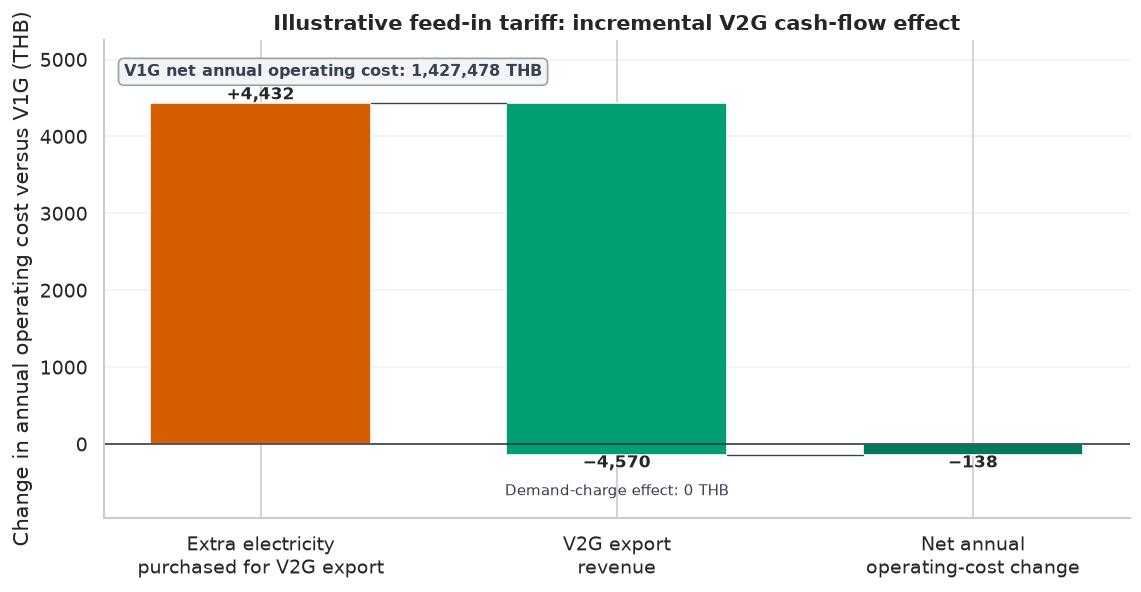

In [7]:
if not missing:
    def import_cost(frame):
        return float((frame['grid_import_MWh'] * frame['electricity_import_price_THB_per_MWh']).sum())

    def export_revenue(frame):
        return float((frame['grid_export_MWh'] * frame['electricity_export_price_THB_per_MWh']).sum())

    delta_import_cost = import_cost(i02b) - import_cost(i01)
    i02b_export_revenue = export_revenue(i02b)
    delta_demand_charge = comparison.loc[i02b_label, 'demand_charge_THB'] - comparison.loc[i01_label, 'demand_charge_THB']
    v1g_total_operating_cost = comparison.loc[i01_label, 'total_cost_THB']
    net_cost_change = comparison.loc[i02b_label, 'total_cost_THB'] - v1g_total_operating_cost

    names = ['Extra electricity\npurchased for V2G export', 'V2G export\nrevenue', 'Net annual\noperating-cost change']
    values = [delta_import_cost, -i02b_export_revenue, net_cost_change]
    bottoms = [0, delta_import_cost + values[1], min(0, net_cost_change)]
    heights = [delta_import_cost, abs(values[1]), abs(net_cost_change)]
    colors = ['#D55E00', '#009E73', '#007A5E']

    fig, axis = plt.subplots(figsize=(9.4, 4.8), constrained_layout=True)
    x = np.arange(3)
    axis.bar(x, heights, bottom=bottoms, color=colors, width=0.62)
    axis.plot([x[0] + 0.31, x[1] - 0.31], [delta_import_cost, delta_import_cost], color='#374151', linewidth=0.8)
    axis.plot([x[1] + 0.31, x[2] - 0.31], [net_cost_change, net_cost_change], color='#374151', linewidth=0.8)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_xticks(x, names)
    axis.set_ylabel('Change in annual operating cost versus V1G (THB)')
    axis.set_title('Illustrative feed-in tariff: incremental V2G cash-flow effect')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    margin = max(delta_import_cost, i02b_export_revenue) * 0.18
    axis.set_ylim(min(net_cost_change - margin, -margin), max(delta_import_cost + margin, margin))
    label_y = [delta_import_cost, bottoms[1], net_cost_change]
    for xpos, value, ypos in zip(x, values, label_y):
        text = f'+{value:,.0f}' if value > 0 else f'−{abs(value):,.0f}' if value < 0 else '0'
        axis.text(xpos, ypos, text, ha='center', va='bottom' if value >= 0 else 'top', fontsize=10, fontweight='semibold')
    axis.text(0.02, 0.95, f'V1G net annual operating cost: {v1g_total_operating_cost:,.0f} THB', transform=axis.transAxes, ha='left', va='top', fontsize=9.5, fontweight='semibold', color='#374151', bbox={'boxstyle': 'round,pad=0.35', 'facecolor': '#F3F4F6', 'edgecolor': '#9AA0A6'})
    axis.text(0.5, 0.04, f'Demand-charge effect: {delta_demand_charge:,.0f} THB', transform=axis.transAxes, ha='center', va='bottom', fontsize=9, color='#374151')
    plt.show()


### Slide messages

**Key finding:** At the current 2.20 THB/kWh feed-in tariff, I02a exports **0 MWh**—the model does not find economic V2G export. At the illustrative 3.20 THB/kWh payment, I02b exports **1.428 MWh/year**, while maintaining zero unmet trip energy.

**Stakeholder conclusion:** The current feed-in tariff does not create a V2G business case for the depot operator. Any Thai export or flexibility pilot must offer a payment that covers conversion losses and operating effects, with 3.20 THB/kWh shown here only as the first tested tariff point that induces export.


## 4. Peak-demand import reduction: technical V2G sensitivity

**Comparison:** V1G managed charging versus I04a at the current 5 kW export-policy limit and I04b at the 450 kW technical sensitivity. “Peak-demand” is selected from the power-system peak-demand proxy; it does not identify a verified local feeder constraint.


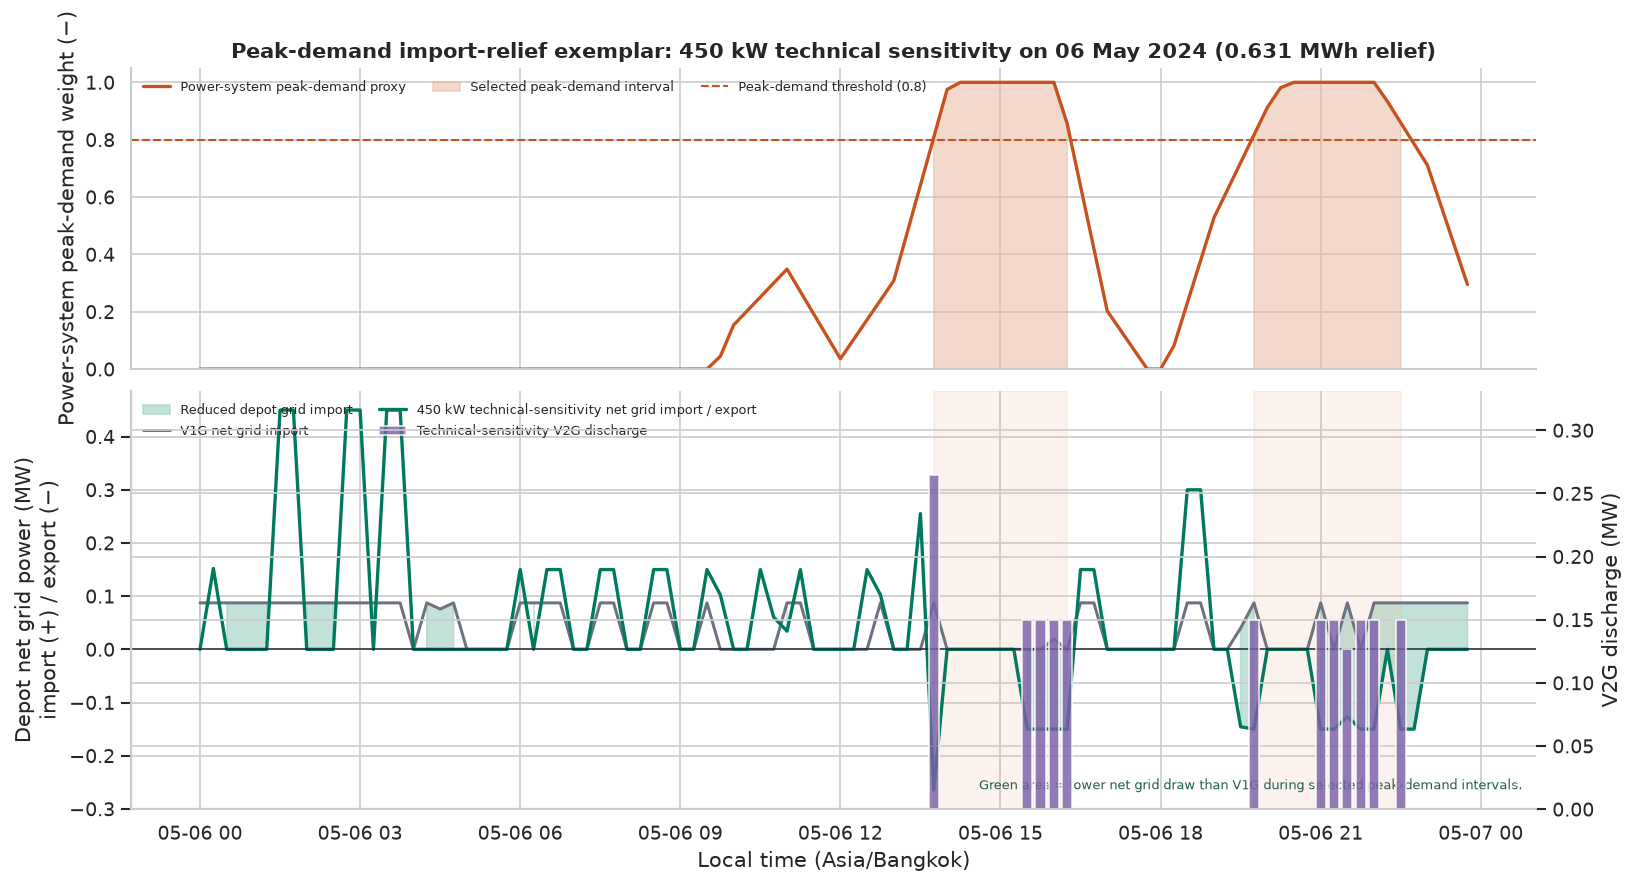

In [8]:
v1g_label = 'V1G baseline'
i04a_label = 'I04a maximum power-system peak-demand import reduction at 5 kW policy limit'
i04b_label = 'I04b maximum power-system peak-demand import reduction at 450 kW technical sensitivity'

high_load_cases = [v1g_label, i04a_label, i04b_label]
missing_high_load = [label for label in high_load_cases if label not in dispatch_by_case or label not in comparison.index]
if missing_high_load:
    print(f'Missing completed peak-demand-case outputs: {missing_high_load}')
else:
    v1g_dispatch = dispatch_by_case[v1g_label].copy()
    i04b_dispatch = dispatch_by_case[i04b_label].copy()
    for frame in (v1g_dispatch, i04b_dispatch):
        frame.index = pd.to_datetime(frame.index)

    common_index = v1g_dispatch.index.intersection(i04b_dispatch.index)
    v1g_profile = v1g_dispatch.loc[common_index]
    i04b_profile = i04b_dispatch.loc[common_index]
    threshold = float(i04b_profile['grid_stress_threshold'].iloc[0])
    high_load = i04b_profile['grid_congestion_weight'] >= threshold
    relief_mwh = v1g_profile['traction_net_grid_import_MWh'] - i04b_profile['traction_net_grid_import_MWh']
    daily_relief = relief_mwh.where(high_load, 0.0).groupby(relief_mwh.index.date).sum()
    selected_day = daily_relief.idxmax()

    v1g_day = v1g_profile.loc[v1g_profile.index.date == selected_day].copy()
    i04b_day = i04b_profile.loc[i04b_profile.index.date == selected_day].copy()
    high_load_day = i04b_day['grid_congestion_weight'] >= threshold
    relief_day_mwh = v1g_day['traction_net_grid_import_MWh'] - i04b_day['traction_net_grid_import_MWh']
    relief_day = float(relief_day_mwh.where(high_load_day, 0.0).sum())

    v1g_power = v1g_day['traction_net_grid_import_MWh'] / 0.25
    i04b_power = i04b_day['traction_net_grid_import_MWh'] / 0.25
    v2g_discharge = i04b_day['bus_discharge_MWh'] / 0.25

    fig, (signal_axis, power_axis) = plt.subplots(2, 1, figsize=(13.5, 7.0), sharex=True, constrained_layout=True, height_ratios=[0.9, 1.25])
    signal_axis.plot(i04b_day.index, i04b_day['grid_congestion_weight'], color='#C7511F', linewidth=2.0, label='Power-system peak-demand proxy')
    signal_axis.fill_between(i04b_day.index, 0, i04b_day['grid_congestion_weight'], where=high_load_day, color='#E8B49A', alpha=0.5, label='Selected peak-demand interval')
    signal_axis.axhline(threshold, color='#C7511F', linewidth=1.25, linestyle='--', label=f'Peak-demand threshold ({threshold:.1f})')
    signal_axis.set_ylim(0, 1.05)
    signal_axis.set_ylabel('Power-system peak-demand weight (−)')
    signal_axis.set_title(f'Peak-demand import-relief exemplar: 450 kW technical sensitivity on {pd.Timestamp(selected_day):%d %b %Y} ({relief_day:.3f} MWh relief)')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    power_axis.fill_between(v1g_day.index, v1g_power, i04b_power, where=(v1g_power > i04b_power), color='#A8D5C9', alpha=0.7, label='Reduced depot grid import')
    power_axis.plot(v1g_day.index, v1g_power, color='#6B7280', linewidth=1.8, label='V1G net grid import')
    power_axis.plot(i04b_day.index, i04b_power, color='#007A5E', linewidth=2.0, label='450 kW technical-sensitivity net grid import / export')
    power_axis.axhline(0, color='#1F2937', linewidth=0.9)
    power_axis.set_ylabel('Depot net grid power (MW)\nimport (+) / export (−)')
    power_axis.set_xlabel('Local time (Asia/Bangkok)')
    power_axis.fill_between(i04b_day.index, 0, 1, where=high_load_day, transform=power_axis.get_xaxis_transform(), color='#E8B49A', alpha=0.16)

    discharge_axis = power_axis.twinx()
    discharge_axis.bar(i04b_day.index, v2g_discharge.where(high_load_day, 0.0), width=0.008, color='#7B61A8', alpha=0.82, label='Technical-sensitivity V2G discharge')
    discharge_axis.set_ylim(0, max(0.05, float(v2g_discharge.max()) * 1.25))
    discharge_axis.set_ylabel('V2G discharge (MW)')

    handles_1, labels_1 = power_axis.get_legend_handles_labels()
    handles_2, labels_2 = discharge_axis.get_legend_handles_labels()
    power_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left', ncol=2, frameon=False, fontsize=8)
    power_axis.text(0.99, 0.04, 'Green area = lower net grid draw than V1G during selected peak-demand intervals.', transform=power_axis.transAxes, ha='right', va='bottom', fontsize=8, color='#245B4F')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


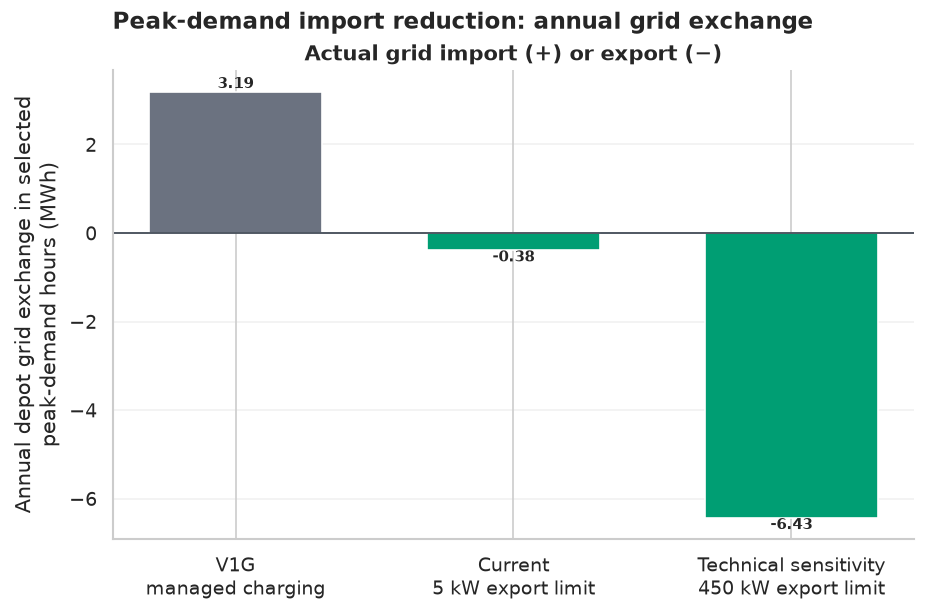

In [9]:
if not missing_high_load:
    def high_load_metrics(case_label):
        case = dispatch_by_case[case_label]
        base = dispatch_by_case[v1g_label]
        common = base.index.intersection(case.index)
        base = base.loc[common]
        case = case.loc[common]
        case_high_load = case['grid_congestion_weight'] >= float(case['grid_stress_threshold'].iloc[0])
        base_net = base['traction_net_grid_import_MWh']
        case_net = case['traction_net_grid_import_MWh']
        relief = base_net - case_net
        return {
            'high_load_net_exchange_MWh': float(case_net.where(case_high_load, 0.0).sum()),
            'high_load_import_relief_MWh': float(relief.where(case_high_load, 0.0).sum()),
            'peak_import_relief_kW': float(relief.max() / 0.25 * 1000),
        }

    metric_rows = {label: high_load_metrics(label) for label in high_load_cases}
    high_load_summary = pd.DataFrame(metric_rows).T
    labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    x = np.arange(len(high_load_cases))
    exchanges = high_load_summary['high_load_net_exchange_MWh'].to_numpy()
    exchange_colors = ['#6B7280' if value > 0 else '#009E73' for value in exchanges]

    fig, exchange_axis = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)
    bars = exchange_axis.bar(x, exchanges, color=exchange_colors, width=0.62)
    exchange_axis.axhline(0, color='#1F2937', linewidth=0.9)
    exchange_axis.set_xticks(x, labels)
    exchange_axis.set_ylabel('Annual depot grid exchange in selected\npeak-demand hours (MWh)')
    exchange_axis.set_title('Actual grid import (+) or export (−)')
    exchange_axis.grid(axis='y', alpha=0.28)
    exchange_axis.set_axisbelow(True)
    for bar, value in zip(bars, exchanges):
        exchange_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.2f}', ha='center', va='bottom' if value >= 0 else 'top', fontsize=9, fontweight='semibold')
    fig.suptitle('Peak-demand import reduction: annual grid exchange', fontsize=14, fontweight='semibold')
    plt.show()


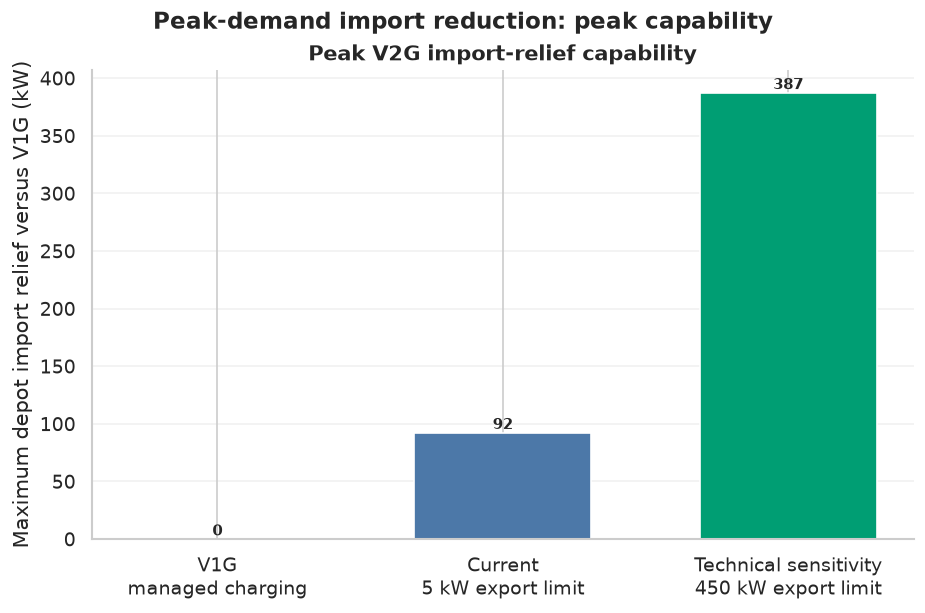

In [10]:
if not missing_high_load:
    peak_relief = high_load_summary['peak_import_relief_kW'].to_numpy()
    fig, relief_axis = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)
    bars = relief_axis.bar(x, peak_relief, color=['#9AA0A6', '#4C78A8', '#009E73'], width=0.62)
    relief_axis.set_xticks(x, labels)
    relief_axis.set_ylabel('Maximum depot import relief versus V1G (kW)')
    relief_axis.set_title('Peak V2G import-relief capability')
    relief_axis.grid(axis='y', alpha=0.28)
    relief_axis.set_axisbelow(True)
    for bar, value in zip(bars, peak_relief):
        relief_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='semibold')
    fig.suptitle('Peak-demand import reduction: peak capability', fontsize=14, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


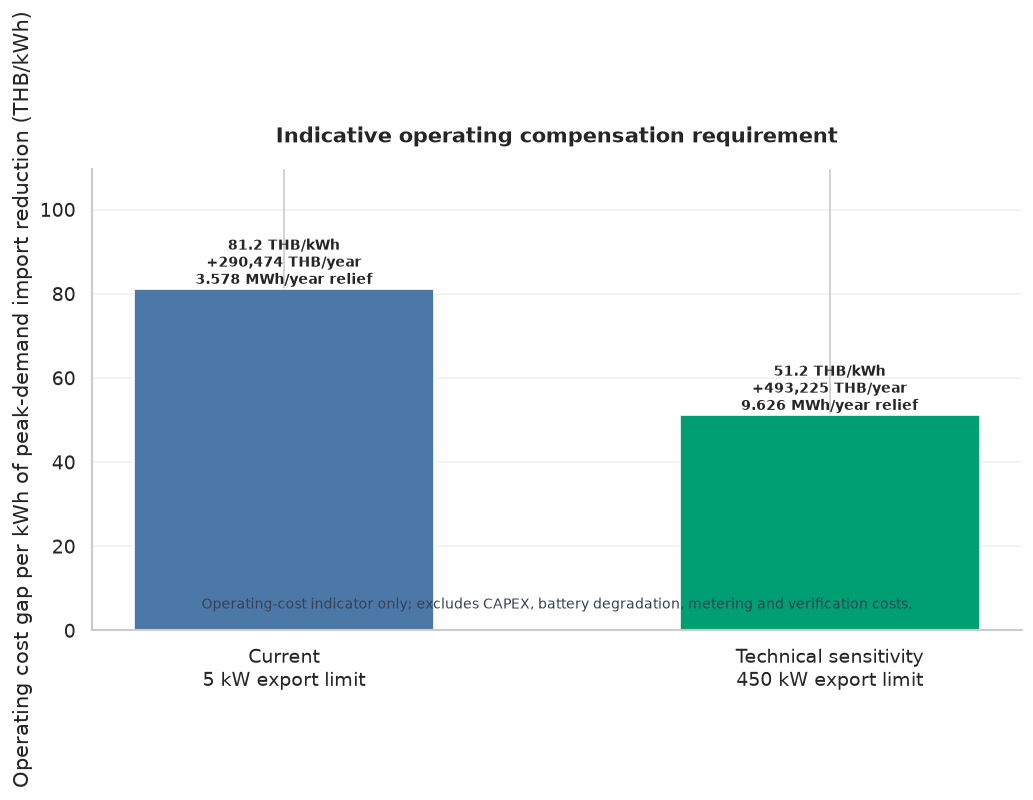

In [11]:
if not missing_high_load:
    compensation = []
    for label in [i04a_label, i04b_label]:
        relief_mwh = high_load_summary.loc[label, 'high_load_import_relief_MWh']
        cost_gap = comparison.loc[label, 'total_cost_THB'] - comparison.loc[v1g_label, 'total_cost_THB']
        compensation.append({
            'case': label,
            'cost_gap_THB': cost_gap,
            'relief_MWh': relief_mwh,
            'cost_gap_THB_per_kWh': cost_gap / (relief_mwh * 1000) if relief_mwh > 0 else np.nan,
        })
    compensation = pd.DataFrame(compensation).set_index('case')
    labels = ['Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    values = compensation['cost_gap_THB_per_kWh'].to_numpy()

    fig, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    bars = axis.bar(labels, values, color=['#4C78A8', '#009E73'], width=0.55)
    axis.set_ylabel('Operating cost gap per kWh of peak-demand import reduction (THB/kWh)')
    axis.set_title('Indicative operating compensation requirement', pad=16)
    axis.set_ylim(0, max(values) * 1.35)
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, case, value in zip(bars, compensation.index, values):
        annual_gap = compensation.loc[case, 'cost_gap_THB']
        relief = compensation.loc[case, 'relief_MWh']
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f} THB/kWh\n+{annual_gap:,.0f} THB/year\n{relief:.3f} MWh/year relief', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    axis.text(0.5, 0.04, 'Operating-cost indicator only; excludes CAPEX, battery degradation, metering and verification costs.', transform=axis.transAxes, ha='center', va='bottom', fontsize=8.5, color='#374151')
    plt.show()


### Slide messages

**Key finding:** During the selected power-system peak-demand hours, I04a reduces the depot’s net grid draw by **3.578 MWh/year** with **92 kW** peak relief under the 5 kW policy limit. I04b reaches **9.626 MWh/year** and **387 kW**, but this is a 450 kW technical sensitivity rather than a current export entitlement.

**Stakeholder conclusion:** A distribution utility can benefit only where the depot’s response coincides with a local network need. The operator faces an indicative operating compensation gap of **81 THB/kWh** for I04a or **51 THB/kWh** for I04b, before CAPEX, degradation and service-verification costs; these figures are not tariff recommendations.


## 5. Renewable-responsive bus charging and discharge

**Comparison:** V1G managed charging versus I06a at the current 5 kW export-policy limit and I06b at the 450 kW technical sensitivity. Renewable availability is a common model proxy: it does not prove the physical source of each metered kWh.


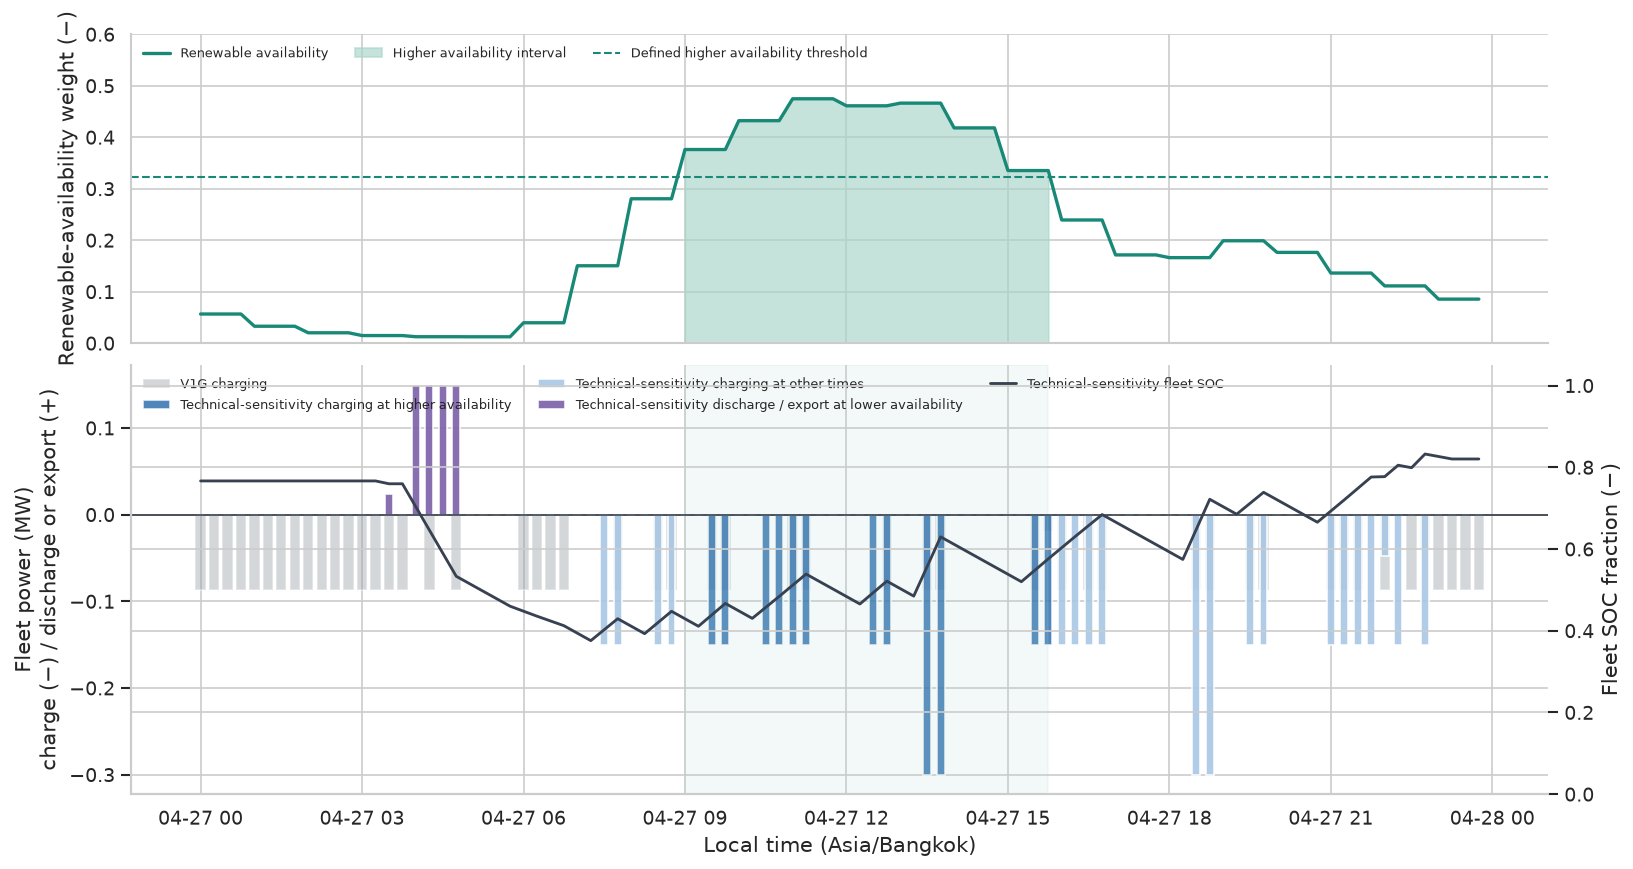

In [12]:
i06a_label = 'I06a maximum renewable-deficit support at 5 kW policy limit'
i06b_label = 'I06b maximum renewable-deficit support at 450 kW technical sensitivity'
renewable_cases = [v1g_label, i06a_label, i06b_label]
missing_renewable = [label for label in renewable_cases if label not in dispatch_by_case or label not in comparison.index]

if missing_renewable:
    print(f'Missing completed renewable-alignment outputs: {missing_renewable}')
else:
    renewable_signal = pd.read_csv(
        INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv',
        usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'],
        parse_dates=['datetime'],
    ).set_index('datetime')
    renewable_signal.index = renewable_signal.index.tz_localize(dispatch_by_case[v1g_label].index.tz)
    renewable_threshold = float(renewable_signal['renewable_rich_threshold'].iloc[0])

    # Use the previously identified illustrative April day; it contains both
    # higher and lower availability intervals and visible I06b discharge.
    selected_day = pd.Timestamp('2024-04-27', tz=dispatch_by_case[v1g_label].index.tz).date()
    v1g_day = dispatch_by_case[v1g_label].loc[dispatch_by_case[v1g_label].index.date == selected_day].copy()
    i06b_day = dispatch_by_case[i06b_label].loc[dispatch_by_case[i06b_label].index.date == selected_day].copy()
    signal_day = renewable_signal.reindex(i06b_day.index)
    higher_availability = signal_day['renewable_availability_weight'] >= renewable_threshold
    weighted_discharge_day = float((i06b_day['bus_discharge_MWh'] * (1 - signal_day['renewable_availability_weight'])).sum())

    v1g_charge_power = v1g_day['bus_charge_MWh'] / 0.25
    i06b_charge_power = i06b_day['bus_charge_MWh'] / 0.25
    i06b_discharge_power = i06b_day['bus_discharge_MWh'] / 0.25
    i06b_soc = i06b_day['bus_soc_fraction']

    fig, (signal_axis, action_axis) = plt.subplots(2, 1, figsize=(13.5, 7.0), sharex=True, constrained_layout=True, height_ratios=[0.9, 1.25])
    signal_axis.plot(signal_day.index, signal_day['renewable_availability_weight'], color='#188977', linewidth=2.0, label='Renewable availability')
    signal_axis.fill_between(signal_day.index, 0, signal_day['renewable_availability_weight'], where=higher_availability, color='#A8D5C9', alpha=0.65, label='Higher availability interval')
    signal_axis.axhline(renewable_threshold, color='#188977', linewidth=1.25, linestyle='--', label='Defined higher availability threshold')
    signal_axis.set_ylim(0, max(0.6, float(signal_day['renewable_availability_weight'].max()) * 1.12))
    signal_axis.set_ylabel('Renewable-availability weight (−)')
    # signal_axis.set_title(f'Renewable-alignment exemplar: I06b on {pd.Timestamp(selected_day):%d %b %Y} ({weighted_discharge_day:.3f} MWh proxy-weighted discharge)')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    action_axis.bar(v1g_day.index, -v1g_charge_power, width=0.008, color='#9AA0A6', alpha=0.42, label='V1G charging')
    action_axis.bar(i06b_day.index, -i06b_charge_power.where(higher_availability, 0.0), width=0.006, color='#2F6FB0', alpha=0.84, label='Technical-sensitivity charging at higher availability')
    action_axis.bar(i06b_day.index, -i06b_charge_power.where(~higher_availability, 0.0), width=0.006, color='#A8C7E5', alpha=0.9, label='Technical-sensitivity charging at other times')
    action_axis.bar(i06b_day.index, i06b_discharge_power.where(~higher_availability, 0.0), width=0.006, color='#7B61A8', alpha=0.9, label='Technical-sensitivity discharge / export at lower availability')
    action_axis.axhline(0, color='#1F2937', linewidth=0.9)
    action_axis.set_ylabel('Fleet power (MW)\ncharge (−) / discharge or export (+)')
    action_axis.set_xlabel('Local time (Asia/Bangkok)')
    action_axis.fill_between(i06b_day.index, 0, 1, where=higher_availability, transform=action_axis.get_xaxis_transform(), color='#A8D5C9', alpha=0.13)

    soc_axis = action_axis.twinx()
    soc_axis.plot(i06b_day.index, i06b_soc, color='#374151', linewidth=1.7, label='Technical-sensitivity fleet SOC')
    soc_axis.set_ylim(0, 1.05)
    soc_axis.set_ylabel('Fleet SOC fraction (−)')
    handles_1, labels_1 = action_axis.get_legend_handles_labels()
    handles_2, labels_2 = soc_axis.get_legend_handles_labels()
    action_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left', ncol=3, frameon=False, fontsize=8)
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


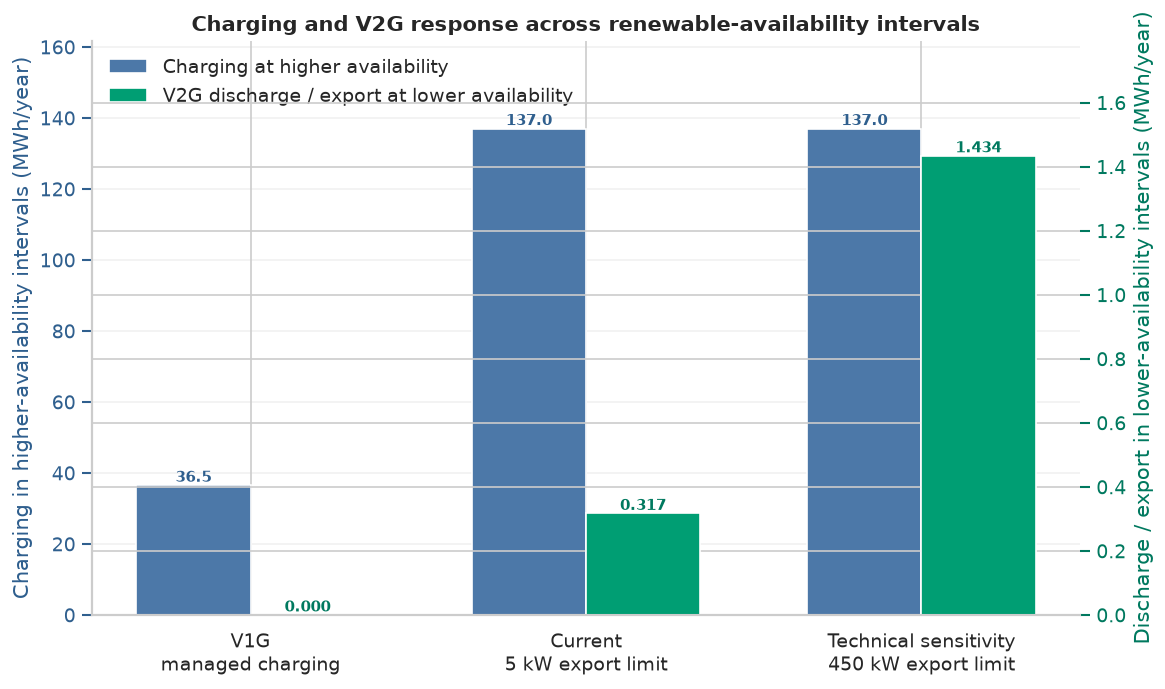

In [13]:
if not missing_renewable:
    def renewable_metrics(case_label):
        dispatch = dispatch_by_case[case_label]
        signal = renewable_signal.reindex(dispatch.index)
        higher = signal['renewable_availability_weight'] >= renewable_threshold
        lower = ~higher
        return {
            'charge_higher_availability_MWh': float(dispatch.loc[higher, 'bus_charge_MWh'].sum()),
            'depot_to_grid_lower_availability_MWh': float(dispatch.loc[lower, 'grid_export_MWh'].sum()),
        }

    renewable_summary = pd.DataFrame({label: renewable_metrics(label) for label in renewable_cases}).T
    display_labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    x = np.arange(len(renewable_cases))
    charge_values = renewable_summary['charge_higher_availability_MWh'].to_numpy()
    export_values = renewable_summary['depot_to_grid_lower_availability_MWh'].to_numpy()
    width = 0.34

    fig, charge_axis = plt.subplots(figsize=(9.6, 5.6), constrained_layout=True)
    export_axis = charge_axis.twinx()
    charge_bars = charge_axis.bar(x - width / 2, charge_values, width, color='#4C78A8', label='Charging at higher availability')
    export_bars = export_axis.bar(x + width / 2, export_values, width, color='#009E73', label='V2G discharge / export at lower availability')
    charge_axis.set_xticks(x, display_labels)
    charge_axis.set_ylabel('Charging in higher-availability intervals (MWh/year)', color='#2F5F8E')
    export_axis.set_ylabel('Discharge / export in lower-availability intervals (MWh/year)', color='#00795F')
    charge_axis.tick_params(axis='y', colors='#2F5F8E')
    export_axis.tick_params(axis='y', colors='#00795F')
    charge_axis.set_title('Charging and V2G response across renewable-availability intervals')
    charge_axis.grid(axis='y', alpha=0.28)
    charge_axis.set_axisbelow(True)
    charge_axis.set_ylim(0, charge_values.max() * 1.18)
    export_axis.set_ylim(0, max(export_values.max() * 1.25, 0.2))
    for bar, value in zip(charge_bars, charge_values):
        charge_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}', ha='center', va='bottom', fontsize=8.8, fontweight='semibold', color='#2F5F8E')
    for bar, value in zip(export_bars, export_values):
        export_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f}', ha='center', va='bottom', fontsize=8.8, fontweight='semibold', color='#00795F')
    handles = [charge_bars, export_bars]
    charge_axis.legend(handles, [handle.get_label() for handle in handles], loc='upper left', frameon=False)
    # fig.suptitle('', fontsize=14, fontweight='semibold')
    plt.show()


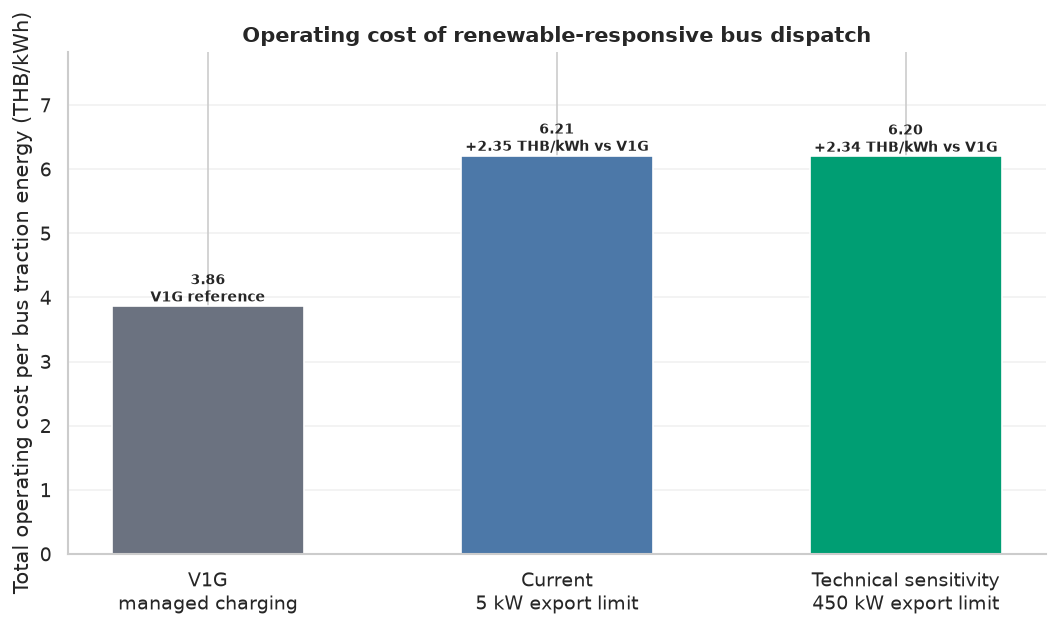

In [14]:
if not missing_renewable:
    cost_rows = []
    for label in renewable_cases:
        trip_energy_mwh = float(dispatch_by_case[label]['bus_trip_energy_MWh'].sum())
        cost_rows.append({
            'case': label,
            'trip_energy_MWh': trip_energy_mwh,
            'total_cost_THB': float(comparison.loc[label, 'total_cost_THB']),
            'operating_cost_THB_per_traction_kWh': float(comparison.loc[label, 'total_cost_THB']) / (trip_energy_mwh * 1000),
        })
    renewable_operator_cost = pd.DataFrame(cost_rows).set_index('case')
    reference_cost = renewable_operator_cost.loc[v1g_label, 'operating_cost_THB_per_traction_kWh']
    renewable_operator_cost['additional_cost_vs_V1G_THB_per_traction_kWh'] = (
        renewable_operator_cost['operating_cost_THB_per_traction_kWh'] - reference_cost
    )
    labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    values = renewable_operator_cost['operating_cost_THB_per_traction_kWh'].to_numpy()

    fig, axis = plt.subplots(figsize=(8.7, 5.0), constrained_layout=True)
    bars = axis.bar(labels, values, color=['#6B7280', '#4C78A8', '#009E73'], width=0.55)
    axis.set_ylabel('Total operating cost per bus traction energy (THB/kWh)')
    axis.set_title('Operating cost of renewable-responsive bus dispatch')
    axis.set_ylim(0, max(values) * 1.26)
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, case, value in zip(bars, renewable_operator_cost.index, values):
        delta = renewable_operator_cost.loc[case, 'additional_cost_vs_V1G_THB_per_traction_kWh']
        suffix = 'V1G reference' if case == v1g_label else f'+{delta:.2f} THB/kWh vs V1G'
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.2f}\n{suffix}', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    plt.show()


### Slide messages

**Key finding:** I06a shifts **137.0 MWh/year** of charging into higher renewable-availability intervals and exports **0.317 MWh/year** in lower-availability intervals. The 450 kW technical sensitivity, I06b, increases lower-availability export to **1.434 MWh/year**.

**Stakeholder conclusion:** Compared with V1G managed charging, renewable-responsive dispatch increases total operating cost from **3.86 THB/kWh** of bus traction to **6.21 THB/kWh** for I06a and **6.20 THB/kWh** for I06b—about **+2.35 THB/kWh**. A future Thai flexibility product would need a measurable renewable signal and a payment that covers this additional operating cost.


## 6. Rooftop solar PV operation

**Comparison:** the PV + unidirectional charging reference, I07b at the current 5 kW export-policy limit, and I07d with rooftop PV and power-system peak-demand management. I07d uses the same current 2.20 THB/kWh feed-in tariff and 5 kW limit, while keeping total operating cost—including demand charges—at or below the least-cost solution in each rolling horizon.


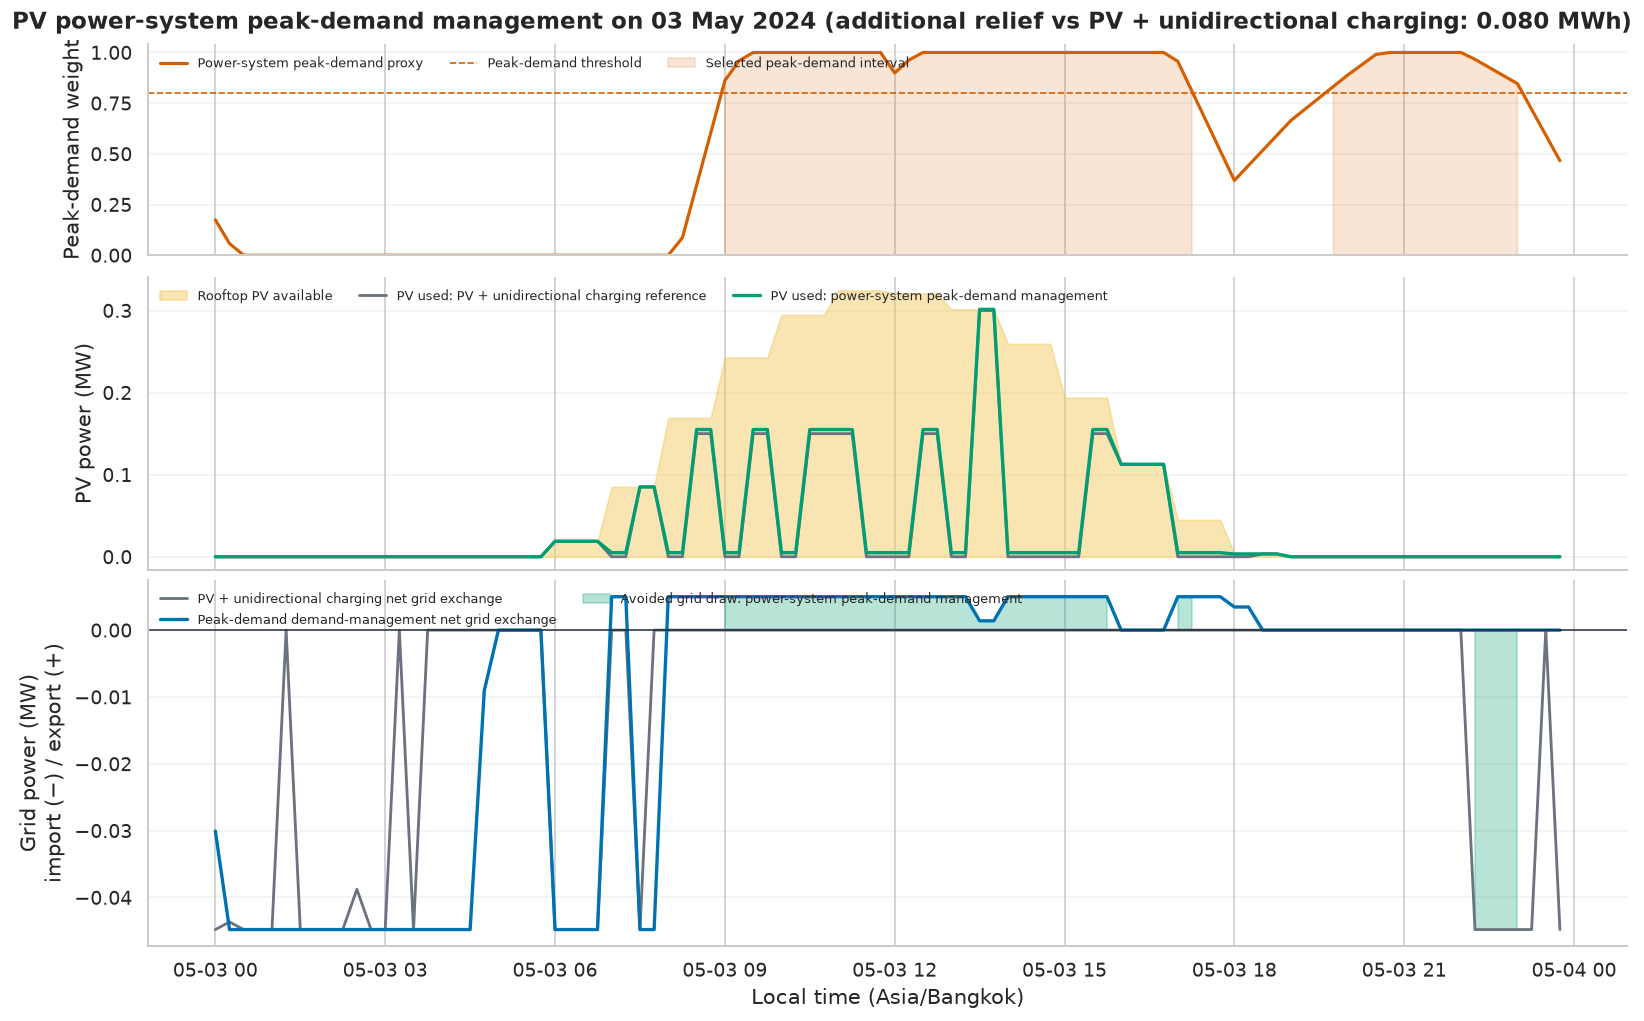

In [15]:
v1g_label = 'V1G baseline'
pv_only_label = 'PV + unidirectional charging reference'
i07b_label = 'I07b rooftop PV operation at current export policy'
i07d_label = 'I07d PV with power-system peak-demand management'
pv_profile_cases = [pv_only_label, i07d_label]
missing_pv_profile = [label for label in pv_profile_cases if label not in dispatch_by_case or label not in comparison.index]
high_load_pv_available = i07d_label in dispatch_by_case and i07d_label in comparison.index

if missing_pv_profile:
    print(f'Missing completed rooftop-PV outputs: {missing_pv_profile}')
else:
    # Choose the day with the largest additional peak-demand-period relief from
    # I07d relative to PV + unidirectional charging.
    pv_only_dispatch = dispatch_by_case[pv_only_label]
    i07d_dispatch = dispatch_by_case[i07d_label]
    high_load = i07d_dispatch['grid_congestion_weight'] >= i07d_dispatch['grid_stress_threshold']
    pv_only_net = pv_only_dispatch['traction_net_grid_import_MWh']
    i07d_net = i07d_dispatch['traction_net_grid_import_MWh']
    relief = (pv_only_net - i07d_net).where(high_load, 0.0)
    daily_relief = relief.groupby(relief.index.normalize()).sum()
    selected_day = daily_relief.idxmax()
    day_mask = i07d_dispatch.index.normalize() == selected_day
    pv_only_day = pv_only_dispatch.loc[day_mask].copy()
    i07d_day = i07d_dispatch.loc[day_mask].copy()
    day_high_load = high_load.loc[day_mask]
    day_relief_mwh = float(relief.loc[day_mask].sum())

    pv_available_mw = i07d_day['pv_available_generation_MWh'] / 0.25
    pv_only_used_mw = pv_only_day['pv_generation_MWh'] / 0.25
    i07d_used_mw = i07d_day['pv_generation_MWh'] / 0.25
    high_load_signal = i07d_day['grid_congestion_weight']
    high_load_threshold = float(i07d_day['grid_stress_threshold'].iloc[0])
    pv_only_grid_power = -pv_only_day['traction_net_grid_import_MWh'] / 0.25
    i07d_grid_power = -i07d_day['traction_net_grid_import_MWh'] / 0.25
    import_relief = i07d_grid_power - pv_only_grid_power

    fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.4), sharex=True, constrained_layout=True,
                             height_ratios=[0.72, 1.0, 1.25])
    signal_axis, pv_axis, exchange_axis = axes

    signal_axis.plot(i07d_day.index, high_load_signal, color='#D55E00', linewidth=1.9,
                     label='Power-system peak-demand proxy')
    signal_axis.axhline(high_load_threshold, color='#D55E00', linestyle='--', linewidth=1.0,
                        label='Peak-demand threshold')
    signal_axis.fill_between(i07d_day.index, 0, high_load_signal, where=day_high_load,
                             color='#D55E00', alpha=0.16, label='Selected peak-demand interval')
    signal_axis.set_ylim(0, 1.04)
    signal_axis.set_ylabel('Peak-demand weight')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    pv_axis.fill_between(i07d_day.index, 0, pv_available_mw, color='#F4C95D', alpha=0.48,
                         label='Rooftop PV available')
    pv_axis.plot(pv_only_day.index, pv_only_used_mw, color='#6B7280', linewidth=1.7,
                 label='PV used: PV + unidirectional charging reference')
    pv_axis.plot(i07d_day.index, i07d_used_mw, color='#009E73', linewidth=2.0,
                 label='PV used: power-system peak-demand management')
    pv_axis.set_ylabel('PV power (MW)')
    pv_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    exchange_axis.plot(pv_only_day.index, pv_only_grid_power, color='#6B7280', linewidth=1.7,
                       label='PV + unidirectional charging net grid exchange')
    exchange_axis.plot(i07d_day.index, i07d_grid_power, color='#0072B2', linewidth=2.0,
                       label='Peak-demand demand-management net grid exchange')
    exchange_axis.fill_between(i07d_day.index, pv_only_grid_power, i07d_grid_power,
                               where=day_high_load & (import_relief > 1e-9), color='#009E73',
                               alpha=0.28, label='Avoided grid draw: power-system peak-demand management')
    exchange_axis.axhline(0, color='#1F2937', linewidth=0.9)
    exchange_axis.set_ylabel('Grid power (MW)\nimport (−) / export (+)')
    exchange_axis.set_xlabel('Local time (Asia/Bangkok)')
    exchange_axis.legend(loc='upper left', ncol=2, frameon=False, fontsize=8)

    for axis in axes:
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    fig.suptitle(
        f'PV power-system peak-demand management on {selected_day:%d %B %Y} '
        f'(additional relief vs PV + unidirectional charging: {day_relief_mwh:.3f} MWh)',
        fontsize=14, fontweight='semibold',
    )
    plt.show()


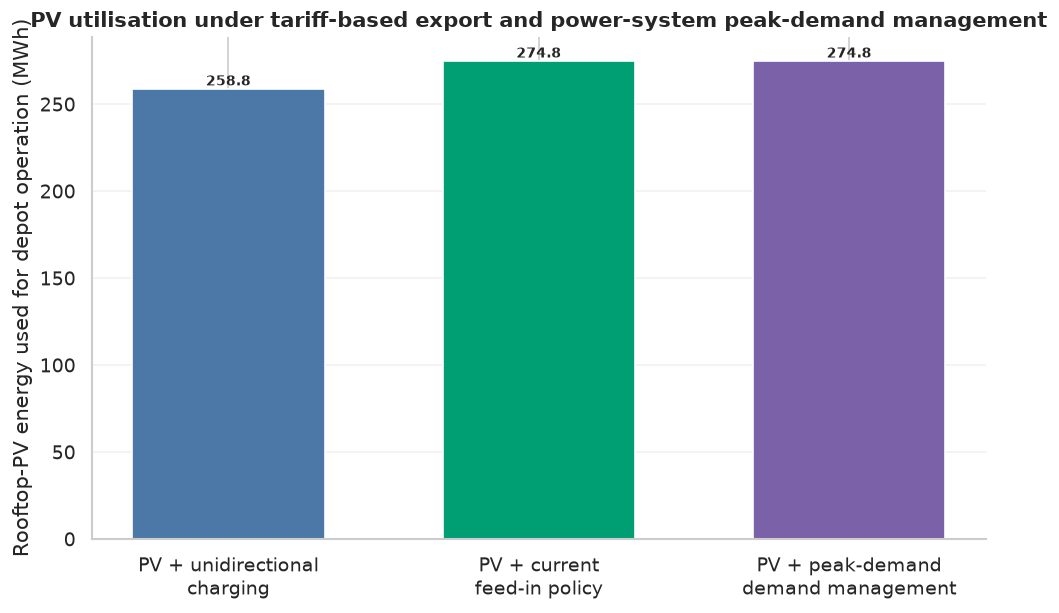

In [16]:
if not missing_pv_profile:
    pv_annual_cases = [pv_only_label, i07b_label]
    if high_load_pv_available:
        pv_annual_cases.append(i07d_label)
    pv_summary = comparison.loc[pv_annual_cases, ['pv_used_MWh', 'pv_curtailment_MWh', 'grid_export_MWh']].copy()
    labels = ['PV + unidirectional\ncharging', 'PV + current\nfeed-in policy']
    colors = ['#4C78A8', '#009E73']
    if high_load_pv_available:
        labels.append('PV + peak-demand\ndemand management')
        colors.append('#7B61A8')
    x = np.arange(len(pv_annual_cases))
    used = pv_summary['pv_used_MWh'].to_numpy()

    fig, use_axis = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
    bars = use_axis.bar(x, used, color=colors, width=0.62)
    use_axis.set_xticks(x, labels)
    use_axis.set_ylabel('Rooftop-PV energy used for depot operation (MWh)')
    use_axis.set_title('PV utilisation under tariff-based export and power-system peak-demand management')
    use_axis.grid(axis='y', alpha=0.28)
    use_axis.set_axisbelow(True)
    for bar, value in zip(bars, used):
        use_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


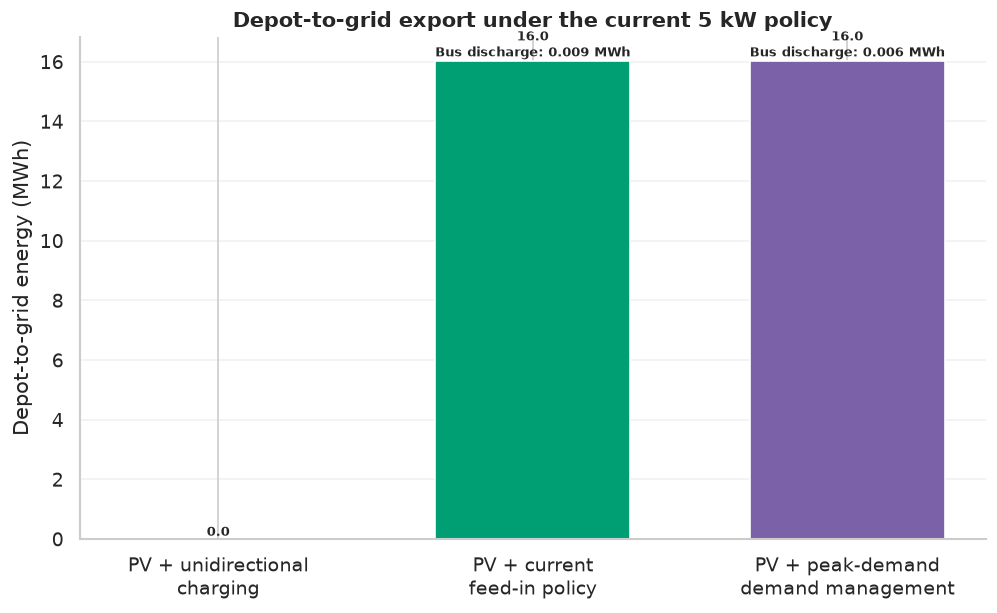

In [17]:
if not missing_pv_profile:
    exported = pv_summary['grid_export_MWh'].to_numpy()
    bus_discharge = [float(dispatch_by_case[label]['bus_discharge_MWh'].sum()) for label in pv_annual_cases]

    fig, export_axis = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
    bars = export_axis.bar(x, exported, color=colors, width=0.62)
    export_axis.set_xticks(x, labels)
    export_axis.set_ylabel('Depot-to-grid energy (MWh)')
    export_axis.set_title('Depot-to-grid export under the current 5 kW policy')
    export_axis.grid(axis='y', alpha=0.28)
    export_axis.set_axisbelow(True)
    for bar, value, discharge in zip(bars, exported, bus_discharge):
        suffix = '' if value == 0 else f'\nBus discharge: {discharge:.3f} MWh'
        export_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}{suffix}', ha='center', va='bottom', fontsize=8.0, fontweight='semibold')
    plt.show()


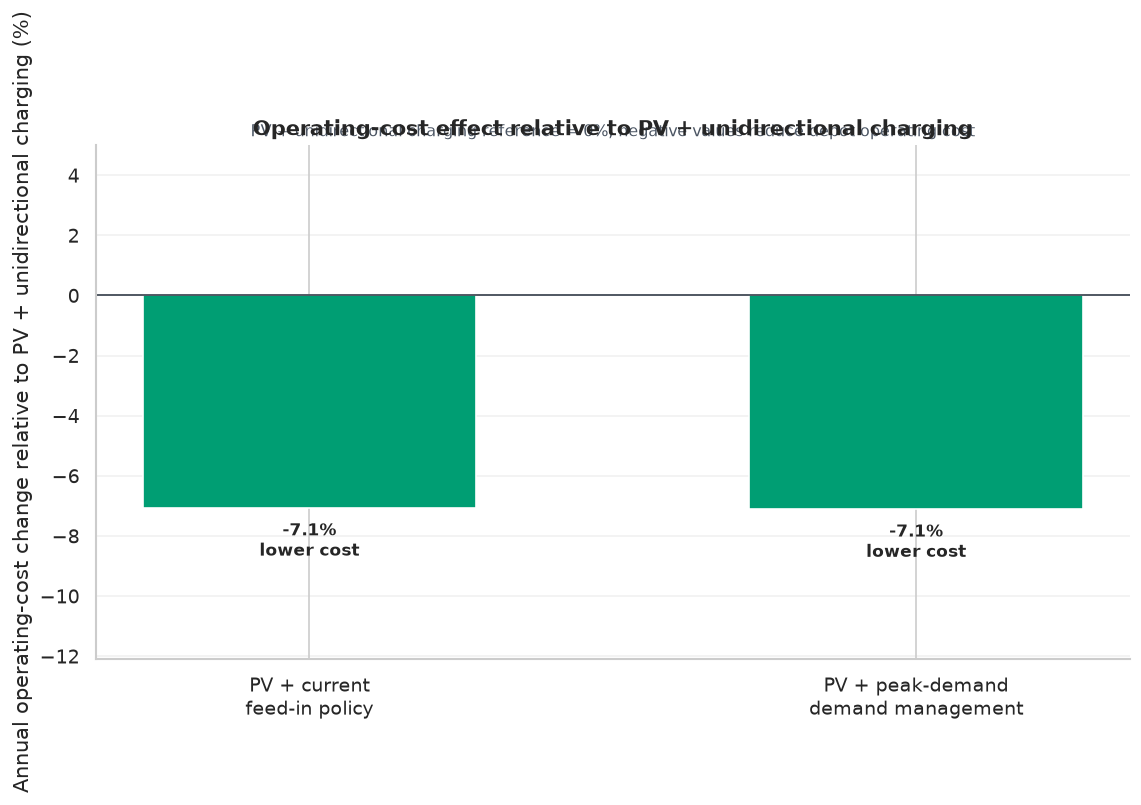

In [18]:
if not missing_pv_profile:
    pv_only_cost = comparison.loc[pv_only_label, 'total_cost_THB']
    cost_labels = [i07b_label]
    if high_load_pv_available:
        cost_labels.append(i07d_label)
    pv_cost_comparison = pd.DataFrame({
        'cost_change_pct': [
            100 * (comparison.loc[label, 'total_cost_THB'] - pv_only_cost) / pv_only_cost
            for label in cost_labels
        ]
    }, index=cost_labels)
    labels = ['PV + current\nfeed-in policy']
    if high_load_pv_available:
        labels.append('PV + peak-demand\ndemand management')
    values = pv_cost_comparison['cost_change_pct'].to_numpy()
    colors = ['#009E73' if value < 0 else '#D55E00' for value in values]

    fig, axis = plt.subplots(figsize=(9.4, 5.1), constrained_layout=True)
    bars = axis.bar(labels, values, color=colors, width=0.55)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_ylabel('Annual operating-cost change relative to PV + unidirectional charging (%)')
    axis.set_title('Operating-cost effect relative to PV + unidirectional charging')
    axis.text(0.5, 1.01, 'PV + unidirectional charging reference = 0%; negative values reduce depot operating cost',
              transform=axis.transAxes, ha='center', va='bottom', fontsize=9.5, color='#4B5563')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    pad = max(abs(values).max() * 0.13, 5)
    axis.set_ylim(min(values.min() - pad, -pad), max(values.max() + pad, pad))
    for bar, value in zip(bars, values):
        direction = 'lower cost' if value < 0 else 'higher cost'
        va = 'top' if value < 0 else 'bottom'
        offset = -8 if value < 0 else 8
        axis.annotate(f'{value:+.1f}%\n{direction}',
                      (bar.get_x() + bar.get_width() / 2, value), xytext=(0, offset),
                      textcoords='offset points', ha='center', va=va, fontsize=10, fontweight='semibold')
    plt.show()


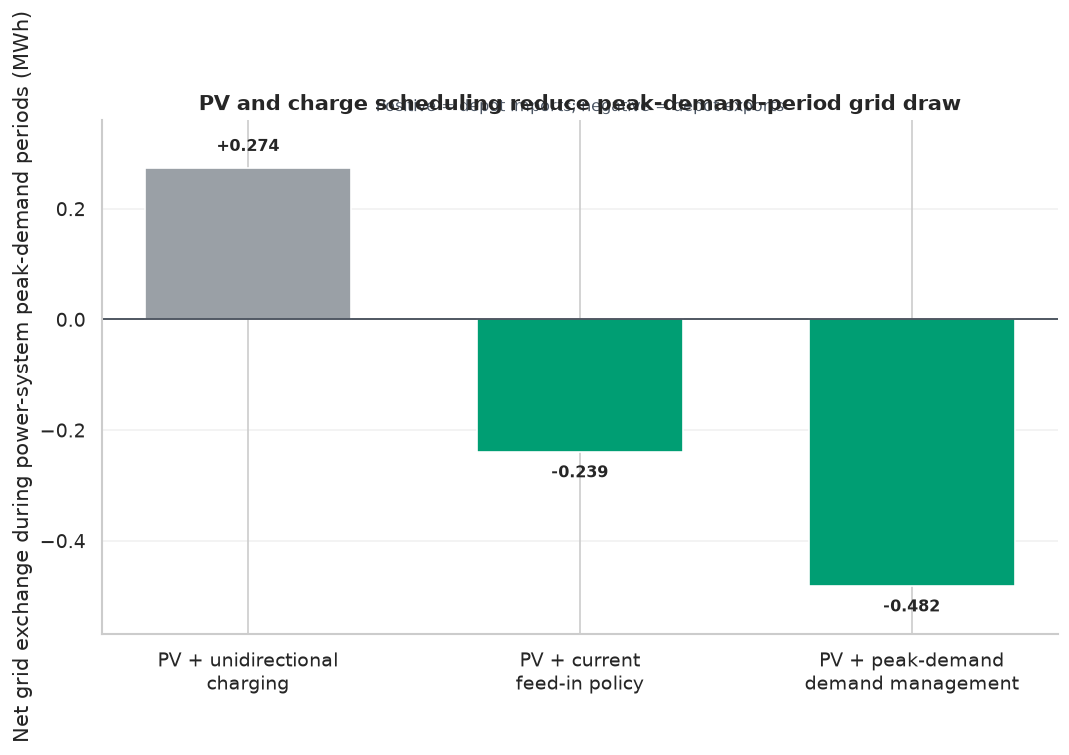

In [19]:
if not missing_pv_profile and high_load_pv_available:
    high_load_cases = [pv_only_label, i07b_label, i07d_label]
    high_load_labels = ['PV + unidirectional\ncharging', 'PV + current\nfeed-in policy', 'PV + peak-demand\ndemand management']
    high_load_rows = []
    for label in high_load_cases:
        dispatch = dispatch_by_case[label]
        high_load = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
        net_exchange = float((dispatch.loc[high_load, 'traction_net_grid_import_MWh']).sum())
        high_load_rows.append(net_exchange)
    high_load_colors = ['#9AA0A6' if value > 0 else '#009E73' for value in high_load_rows]

    fig, axis = plt.subplots(figsize=(8.8, 5.1), constrained_layout=True)
    bars = axis.bar(high_load_labels, high_load_rows, color=high_load_colors, width=0.62)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_ylabel('Net grid exchange during power-system peak-demand periods (MWh)')
    axis.set_title('PV and charge scheduling reduce peak-demand-period grid draw')
    axis.text(0.5, 1.01, 'Positive = depot imports; negative = depot exports',
              transform=axis.transAxes, ha='center', va='bottom', fontsize=9.5, color='#4B5563')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    span = max(max(abs(value) for value in high_load_rows) * 0.18, 0.08)
    axis.set_ylim(min(high_load_rows) - span, max(high_load_rows) + span)
    for bar, value in zip(bars, high_load_rows):
        va = 'top' if value < 0 else 'bottom'
        offset = -8 if value < 0 else 8
        axis.annotate(f'{value:+.3f}', (bar.get_x() + bar.get_width() / 2, value),
                      xytext=(0, offset), textcoords='offset points', ha='center', va=va,
                      fontsize=9.5, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


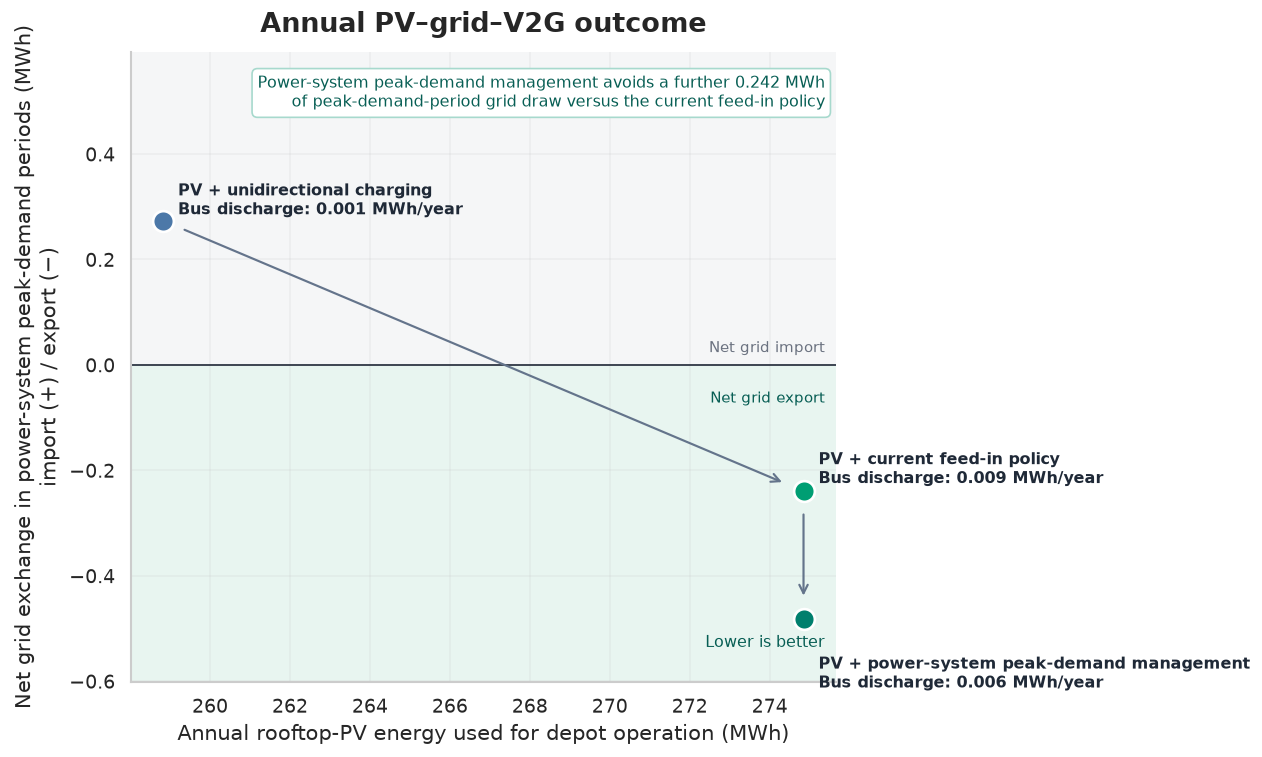

In [20]:
if not missing_pv_profile and high_load_pv_available:
    annual_map_cases = [pv_only_label, i07b_label, i07d_label]
    annual_map_labels = [
        'PV + unidirectional charging',
        'PV + current feed-in policy',
        'PV + power-system peak-demand management',
    ]
    annual_map_colors = ['#4C78A8', '#009E73', '#007F6D']
    annual_map_rows = []
    for label in annual_map_cases:
        dispatch = dispatch_by_case[label]
        high_load = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
        annual_map_rows.append({
            'case': label,
            'pv_used_MWh': float(pv_summary.loc[label, 'pv_used_MWh']),
            'high_load_exchange_MWh': float(
                dispatch.loc[high_load, 'traction_net_grid_import_MWh'].sum()
            ),
            'bus_discharge_MWh': float(dispatch['bus_discharge_MWh'].sum()),
        })
    annual_map = pd.DataFrame(annual_map_rows, index=annual_map_labels)

    fig, axis = plt.subplots(figsize=(10.4, 6.2), constrained_layout=True)
    y_min = annual_map['high_load_exchange_MWh'].min() - 0.12
    y_max = annual_map['high_load_exchange_MWh'].max() + 0.32
    axis.axhspan(y_min, 0, color='#E8F5F0', zorder=0)
    axis.axhspan(0, y_max, color='#F5F6F7', zorder=0)
    axis.axhline(0, color='#1F2937', linewidth=1.0, zorder=1)

    for index, label in enumerate(annual_map_labels):
        row = annual_map.loc[label]
        axis.scatter(
            row['pv_used_MWh'], row['high_load_exchange_MWh'],
            s=155, color=annual_map_colors[index], edgecolor='white', linewidth=1.6,
            zorder=4,
        )

    arrow_pairs = list(zip(annual_map_labels[:-1], annual_map_labels[1:]))
    for start, end in arrow_pairs:
        start_row = annual_map.loc[start]
        end_row = annual_map.loc[end]
        axis.annotate(
            '',
            xy=(end_row['pv_used_MWh'], end_row['high_load_exchange_MWh']),
            xytext=(start_row['pv_used_MWh'], start_row['high_load_exchange_MWh']),
            arrowprops=dict(arrowstyle='->', color='#64748B', linewidth=1.3,
                            shrinkA=14, shrinkB=14),
            zorder=2,
        )

    offsets = {
        'PV + unidirectional charging': (9, 12),
        'PV + current feed-in policy': (9, 13),
        'PV + power-system peak-demand management': (9, -33),
    }
    for label in annual_map_labels:
        row = annual_map.loc[label]
        axis.annotate(
            f'{label}\nBus discharge: {row["bus_discharge_MWh"]:.3f} MWh/year',
            (row['pv_used_MWh'], row['high_load_exchange_MWh']),
            xytext=offsets[label], textcoords='offset points', ha='left', va='center',
            fontsize=9.4, fontweight='semibold', color='#1F2937', zorder=5,
        )

    i07b_exchange = annual_map.loc['PV + current feed-in policy', 'high_load_exchange_MWh']
    i07d_exchange = annual_map.loc['PV + power-system peak-demand management', 'high_load_exchange_MWh']
    additional_relief = i07b_exchange - i07d_exchange
    axis.text(
        0.985, 0.965,
        f'Power-system peak-demand management avoids a further {additional_relief:.3f} MWh\nof peak-demand-period grid draw versus the current feed-in policy',
        transform=axis.transAxes, ha='right', va='top', fontsize=9.4, color='#075E54',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#A7D9CD'),
    )
    axis.text(0.985, 0.05, 'Lower is better', transform=axis.transAxes,
              ha='right', va='bottom', fontsize=9.4, color='#075E54')
    axis.text(0.985, 0.53, 'Net grid import', transform=axis.transAxes,
              ha='right', va='center', fontsize=9, color='#6B7280')
    axis.text(0.985, 0.45, 'Net grid export', transform=axis.transAxes,
              ha='right', va='center', fontsize=9, color='#075E54')
    axis.set_title('Annual PV–grid–V2G outcome', fontsize=16, fontweight='semibold', pad=12)
    axis.set_xlabel('Annual rooftop-PV energy used for depot operation (MWh)')
    axis.set_ylabel('Net grid exchange in power-system peak-demand periods (MWh)\nimport (+) / export (−)')
    axis.set_ylim(y_min, y_max)
    axis.grid(alpha=0.22)
    axis.set_axisbelow(True)
    plt.show()


### Slide messages

**Key finding:** With rooftop PV and unidirectional charging, the depot uses **258.8 MWh/year** of on-site solar electricity and imports **130.3 MWh/year** from the grid for traction. Under the current **2.20 THB/kWh feed-in tariff** and **5 kW export limit**, I07b increases PV use and depot-to-grid export by **16.0 MWh/year**. Bus discharge is only **0.009 MWh/year**, so the result is primarily surplus-PV export and reduced curtailment.

**I07d comparison:** With the same tariff and 5 kW limit, I07d applies peak-demand-aware charge scheduling without increasing modelled operating cost or demand charges. It changes peak-demand-period net grid exchange from **+0.274 MWh (PV + unidirectional charging)** to **−0.482 MWh**, and reduces annual operating cost by **7.1%** relative to the PV + unidirectional charging reference. Bus discharge remains negligible (**0.006 MWh/year**, with none in peak-demand intervals): the result comes from PV use, surplus-PV export and deferred charging—not from buses discharging to the grid.

**Stakeholder conclusion:** Under the current tariff arrangement, rooftop PV can reduce depot cost and peak-demand-period grid draw, but it does not yet create a material incentive for bus discharge. A future bus-V2G service would need a defined service, suitable bidirectional connection, measurement and settlement, and compensation for the bus operator.
